<a href="https://colab.research.google.com/github/CharlieHubbard7/NFLResearch/blob/main/(6_23_26)_NFL_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFL Research

This notebook contains my work for the sixth week of work with Professor Ron Yurko at Carnegie Mellon's Sports Analytics Center. I use Madden ratings to explore what stats teams value in players of different position groups

##Data Wrangling

### Installs and Imports


In [ ]:
!pip install nflreadpy #This is from the NFLverse package: https://github.com/nflverse/nflreadpy
!pip install rapidfuzz -q #This helps match the NFL roster with the madden data
!pip install lifelines

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 17.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0b22e8d0ab8a5b54741e543c2a43af66f62e6f0d3dbaba45e78ceba738a15b00
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import numpy as np
import string
import re
from scipy import stats
from scipy.stats import zscore
import math
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import nflreadpy as nfl
from rapidfuzz import fuzz, process
pd.set_option('display.max_columns', 250)
pd.set_option('display.min_rows', 10)

### NFL Verse Stats

In [ ]:
pbp = nfl.load_pbp().to_pandas() # play-by-play data
player_stats = nfl.load_player_stats().to_pandas() # player game or season statistics
team_stats = nfl.load_team_stats().to_pandas() # team game or season statistics
# schedules = nfl.load_schedules().to_pandas() # game schedules and results
players = nfl.load_players().to_pandas() # player information
rosters = nfl.load_rosters().to_pandas() # team rosters
rosters_weekly = nfl.load_rosters_weekly().to_pandas() # team rosters by season-week
snap_counts = nfl.load_snap_counts().to_pandas() # snap counts
nextgen_stats = nfl.load_nextgen_stats().to_pandas() # advanced stats from nextgenstats.nfl.com
ftn_charting = nfl.load_ftn_charting().to_pandas() # charted stats from ftnfantasy.com/data
participation = nfl.load_participation().to_pandas() # participation data (historical)
draft_picks = nfl.load_draft_picks().to_pandas() # nfl draft picks
injuries = nfl.load_injuries().to_pandas() # injury statuses and practice participation
contracts = nfl.load_contracts().to_pandas() # historical contract data from OTC
officials = nfl.load_officials().to_pandas() # officials for each game
combine = nfl.load_combine().to_pandas() # nfl combine results
depth_charts = nfl.load_depth_charts().to_pandas() # depth charts
trades = nfl.load_trades().to_pandas() # trades
ff_playerids = nfl.load_ff_playerids().to_pandas() # ffverse/dynastyprocess player ids
ff_rankings = nfl.load_ff_rankings().to_pandas() # fantasypros rankings
ff_opportunity = nfl.load_ff_opportunity().to_pandas() # expected yards, touchdowns, and fantasy points

### Historical Madden Data

Credit to: https://github.com/theedgepredictor/nfl-madden-data/tree/main/data/madden/dataset for the data collection

In [ ]:
madden_long = pd.read_parquet("/content/drive/MyDrive/ipynb stuff/madden_hist.parquet")
combine = nfl.load_combine().to_pandas() # nfl combine results
madden_long.head()

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year
0,00-0004543,SHANEDRONETT_d_line,DronSh20,Shane Dronett,def,d_line,DL,2001,ATL,1.0,75.0,53.0,65.0,58.0,79.0,84.0,84.0,79.0,81.0,43.0,7.347195,4,11,35.306958,66.518996,11.0,20.0,20.0,20.0,16.696763,19.318944,28.0,-2.261149,-1.546120,2.340851,3.478826,22.0,6.519022,10.549796,11.996476,9.005981,8.412261,8.034401,16.0,16.0,0.483380,15.249485,17.082539,81.0,51.752871,8.673651,66.456748,21.0,24.0,0.675884,2001
1,00-0012842,JASONPETER_d_line,PeteJa20,Jason Peter,def,d_line,DL,2001,CAR,1.0,74.0,66.0,74.0,64.0,84.0,78.0,84.0,80.0,67.0,51.0,7.889415,5,7,47.836493,58.864012,10.0,21.0,21.0,21.0,18.295792,21.480056,24.0,0.980120,-0.375920,8.238861,7.495244,21.0,5.982346,9.869347,12.073328,5.724684,4.637821,9.797546,27.0,18.0,9.782409,19.028072,23.221269,72.0,54.472249,12.652961,69.286862,18.0,19.0,3.772098,2001
2,00-0009978,LEONARDLITTLE_d_line,LittLe00,Leonard Little,def,d_line,DL,2001,LAR,1.0,73.0,72.0,62.0,75.0,65.0,70.0,70.0,82.0,64.0,52.0,25.090824,8,9,51.656422,55.302556,32.0,14.0,14.0,14.0,11.934877,13.800475,24.0,19.994085,18.021897,24.959818,21.045019,40.0,8.751804,11.499611,12.645619,17.544412,14.431167,17.109987,16.0,24.0,-5.096101,32.979157,37.209780,74.0,51.286358,28.416331,72.007990,11.0,33.0,1.131921,2001
3,00-0002142,JUNIORBRYANT_d_line,BryaJu20,Junior Bryant,def,d_line,DL,2001,SF,1.0,72.0,49.0,62.0,55.0,81.0,81.0,84.0,84.0,79.0,43.0,5.111116,5,9,36.576845,65.727568,24.0,11.0,11.0,11.0,9.494538,11.093699,14.0,-8.819708,-2.912042,-5.407254,-5.493794,14.0,7.008726,10.117281,12.240143,-1.108932,-1.319240,1.354661,29.0,27.0,7.181824,14.503342,17.728221,82.0,51.302609,6.509206,64.948565,12.0,14.0,1.162361,2001
4,00-0018054,REINARDWILSON_d_line,WilsRe20,Reinard Wilson,def,d_line,DL,2001,CIN,1.0,69.0,70.0,70.0,65.0,78.0,69.0,78.0,77.0,65.0,50.0,16.121217,7,9,50.852213,56.274011,31.0,16.0,16.0,16.0,16.041897,17.385281,26.0,12.748664,9.218156,18.243457,14.183115,26.0,7.190139,10.575620,11.980324,12.149089,9.289694,10.978948,13.0,9.0,-2.869764,26.808503,31.008670,69.0,51.400124,22.833778,69.883798,17.0,21.0,2.545349,2001


### Main df

In [ ]:
contracts = nfl.load_contracts().to_pandas() # historical contract data from OTC
players = nfl.load_players().to_pandas() # player information

In [ ]:
contracts2 = contracts.merge(players[["gsis_id", "rookie_season", "last_season"]], left_on="gsis_id", right_on="gsis_id", how="left")
contracts_short = contracts2[["player", "gsis_id", "year_signed", "apy_cap_pct", "rookie_season", "last_season"]]

In [ ]:
position_summary_madden_long = (
    madden_long
    .groupby(["position_group", "year"])["overallrating"]
    .agg(
        mean_overall="mean",
        median_overall="median",
        n="count",
        sd="std"
    )
    .reset_index()
)

position_summary_madden_long

,position_group,year,mean_overall,median_overall,n,sd
0,d_field,2001,68.664064,69.000000,365,10.288611
1,d_field,2002,67.711419,66.000000,362,11.526267
2,d_field,2003,71.794387,70.000000,378,10.003572
3,d_field,2004,74.369028,72.733159,373,9.849298
4,d_field,2005,75.305321,74.000000,389,9.393804
...,...,...,...,...,...,...
219,special_teams,2021,73.408182,72.658907,146,4.759313
220,special_teams,2022,73.720232,73.000000,137,4.613147
221,special_teams,2023,74.168932,74.000000,122,4.792615
222,special_teams,2024,73.902958,74.000000,140,4.826510


In [ ]:
structure = madden_long.groupby("year")["player_id"].count().reset_index(name="n")

In [ ]:
new_summary = (
    madden_long.groupby(['position_group', 'year'])
    .agg(
        mean_overall  = ('overallrating',  'mean'),
        median_overall= ('overallrating',  'median'),
        n             = ('player_id',      'nunique'),
        overall_sd = ("overallrating", "std"),
    )
    .reset_index()
    .round(3)
)

display(new_summary)

,position_group,year,mean_overall,median_overall,n,overall_sd
0,d_field,2001,68.664,69.000,353,10.289
1,d_field,2002,67.711,66.000,352,11.526
2,d_field,2003,71.794,70.000,344,10.004
3,d_field,2004,74.369,72.733,351,9.849
4,d_field,2005,75.305,74.000,365,9.394
...,...,...,...,...,...,...
219,special_teams,2021,73.408,72.659,146,4.759
220,special_teams,2022,73.720,73.000,137,4.613
221,special_teams,2023,74.169,74.000,122,4.793
222,special_teams,2024,73.903,74.000,140,4.827


In [ ]:
madden_short = madden_long[["fullname", "player_id", "position_group", "overallrating", "year"]]
madden_short = madden_short.merge(new_summary, left_on=["position_group", "year"], right_on=["position_group", "year"], how="left")
madden_short

,fullname,player_id,position_group,overallrating,year,mean_overall,median_overall,n,overall_sd
0,Shane Dronett,00-0004543,d_line,75.000000,2001,69.036,67.441,321,10.346
1,Jason Peter,00-0012842,d_line,74.000000,2001,69.036,67.441,321,10.346
2,Leonard Little,00-0009978,d_line,73.000000,2001,69.036,67.441,321,10.346
3,Junior Bryant,00-0002142,d_line,72.000000,2001,69.036,67.441,321,10.346
4,Reinard Wilson,00-0018054,d_line,69.000000,2001,69.036,67.441,321,10.346
...,...,...,...,...,...,...,...,...,...
62325,Jake Bates,00-0039172,special_teams,76.000000,2025,73.079,74.000,136,5.916
62326,Riley Dixon,00-0032943,special_teams,76.000000,2025,73.079,74.000,136,5.916
62327,Tory Taylor,00-0039745,special_teams,75.000000,2025,73.079,74.000,136,5.916
62328,Blake Grupe,00-0038905,special_teams,73.000000,2025,73.079,74.000,136,5.916


In [ ]:
madden_short["z_overall"] = (madden_short["overallrating"] - madden_short["median_overall"]) / madden_short["overall_sd"]
madden_short.dropna(subset=["player_id"], inplace=True)
madden_short.head()

,fullname,player_id,position_group,overallrating,year,mean_overall,median_overall,n,overall_sd,z_overall
0,Shane Dronett,00-0004543,d_line,75.0,2001,69.036,67.441,321,10.346,0.730621
1,Jason Peter,00-0012842,d_line,74.0,2001,69.036,67.441,321,10.346,0.633965
2,Leonard Little,00-0009978,d_line,73.0,2001,69.036,67.441,321,10.346,0.537309
3,Junior Bryant,00-0002142,d_line,72.0,2001,69.036,67.441,321,10.346,0.440653
4,Reinard Wilson,00-0018054,d_line,69.0,2001,69.036,67.441,321,10.346,0.150686


In [ ]:
madden_short = madden_short.merge(players[["gsis_id", "display_name", "rookie_season", "last_season"]], left_on = "player_id", right_on = "gsis_id", how = "left")

In [ ]:
madden_short.dropna(subset=["player_id"], inplace=True)
madden_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58616 entries, 0 to 58615
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fullname        58616 non-null  object 
 1   player_id       58616 non-null  object 
 2   position_group  58616 non-null  object 
 3   overallrating   58616 non-null  float64
 4   year            58616 non-null  int64  
 5   mean_overall    58616 non-null  float64
 6   median_overall  58616 non-null  float64
 7   n               58616 non-null  int64  
 8   overall_sd      58616 non-null  float64
 9   z_overall       58616 non-null  float64
 10  gsis_id         58232 non-null  object 
 11  display_name    58232 non-null  object 
 12  rookie_season   58232 non-null  float64
 13  last_season     58232 non-null  float64
dtypes: float64(7), int64(2), object(5)
memory usage: 6.3+ MB


In [ ]:
madden_short["year_number"] = madden_short["year"] - madden_short["rookie_season"] + 1
madden_short.query("year_number > 0")

,fullname,player_id,position_group,overallrating,year,mean_overall,median_overall,n,overall_sd,z_overall,gsis_id,display_name,rookie_season,last_season,year_number
0,Shane Dronett,00-0004543,d_line,75.000000,2001,69.036,67.441,321,10.346,0.730621,00-0004543,Shane Dronett,1992.0,2002.0,10.0
1,Jason Peter,00-0012842,d_line,74.000000,2001,69.036,67.441,321,10.346,0.633965,00-0012842,Jason Peter,1998.0,2001.0,4.0
2,Leonard Little,00-0009978,d_line,73.000000,2001,69.036,67.441,321,10.346,0.537309,00-0009978,Leonard Little,1998.0,2009.0,4.0
3,Junior Bryant,00-0002142,d_line,72.000000,2001,69.036,67.441,321,10.346,0.440653,00-0002142,Junior Bryant,1995.0,2002.0,7.0
4,Reinard Wilson,00-0018054,d_line,69.000000,2001,69.036,67.441,321,10.346,0.150686,00-0018054,Reinard Wilson,1997.0,2003.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58611,Jake Bates,00-0039172,special_teams,76.000000,2025,73.079,74.000,136,5.916,0.338066,00-0039172,Jake Bates,2024.0,2026.0,2.0
58612,Riley Dixon,00-0032943,special_teams,76.000000,2025,73.079,74.000,136,5.916,0.338066,00-0032943,Riley Dixon,2016.0,2026.0,10.0
58613,Tory Taylor,00-0039745,special_teams,75.000000,2025,73.079,74.000,136,5.916,0.169033,00-0039745,Tory Taylor,2024.0,2026.0,2.0
58614,Blake Grupe,00-0038905,special_teams,73.000000,2025,73.079,74.000,136,5.916,-0.169033,00-0038905,Blake Grupe,2023.0,2025.0,3.0


In [ ]:
madden_short = madden_short.query("year_number > 0")

In [ ]:
summary = madden_short.groupby(["position_group", "year_number"]).agg(
    mean_z=("z_overall", "mean"),
    median_z=("z_overall", "median"),
    n=("player_id", "count")
).reset_index()

summary

,position_group,year_number,mean_z,median_z,n
0,d_field,1.0,-0.519213,-0.647668,2174
1,d_field,2.0,-0.216889,-0.363020,1843
2,d_field,3.0,0.057559,-0.123183,1554
3,d_field,4.0,0.299563,0.153292,1288
4,d_field,5.0,0.500254,0.394270,1016
...,...,...,...,...,...
181,special_teams,22.0,1.002103,0.850495,6
182,special_teams,23.0,1.131052,1.062295,4
183,special_teams,24.0,0.879672,0.879672,1
184,special_teams,25.0,1.294162,1.294162,2


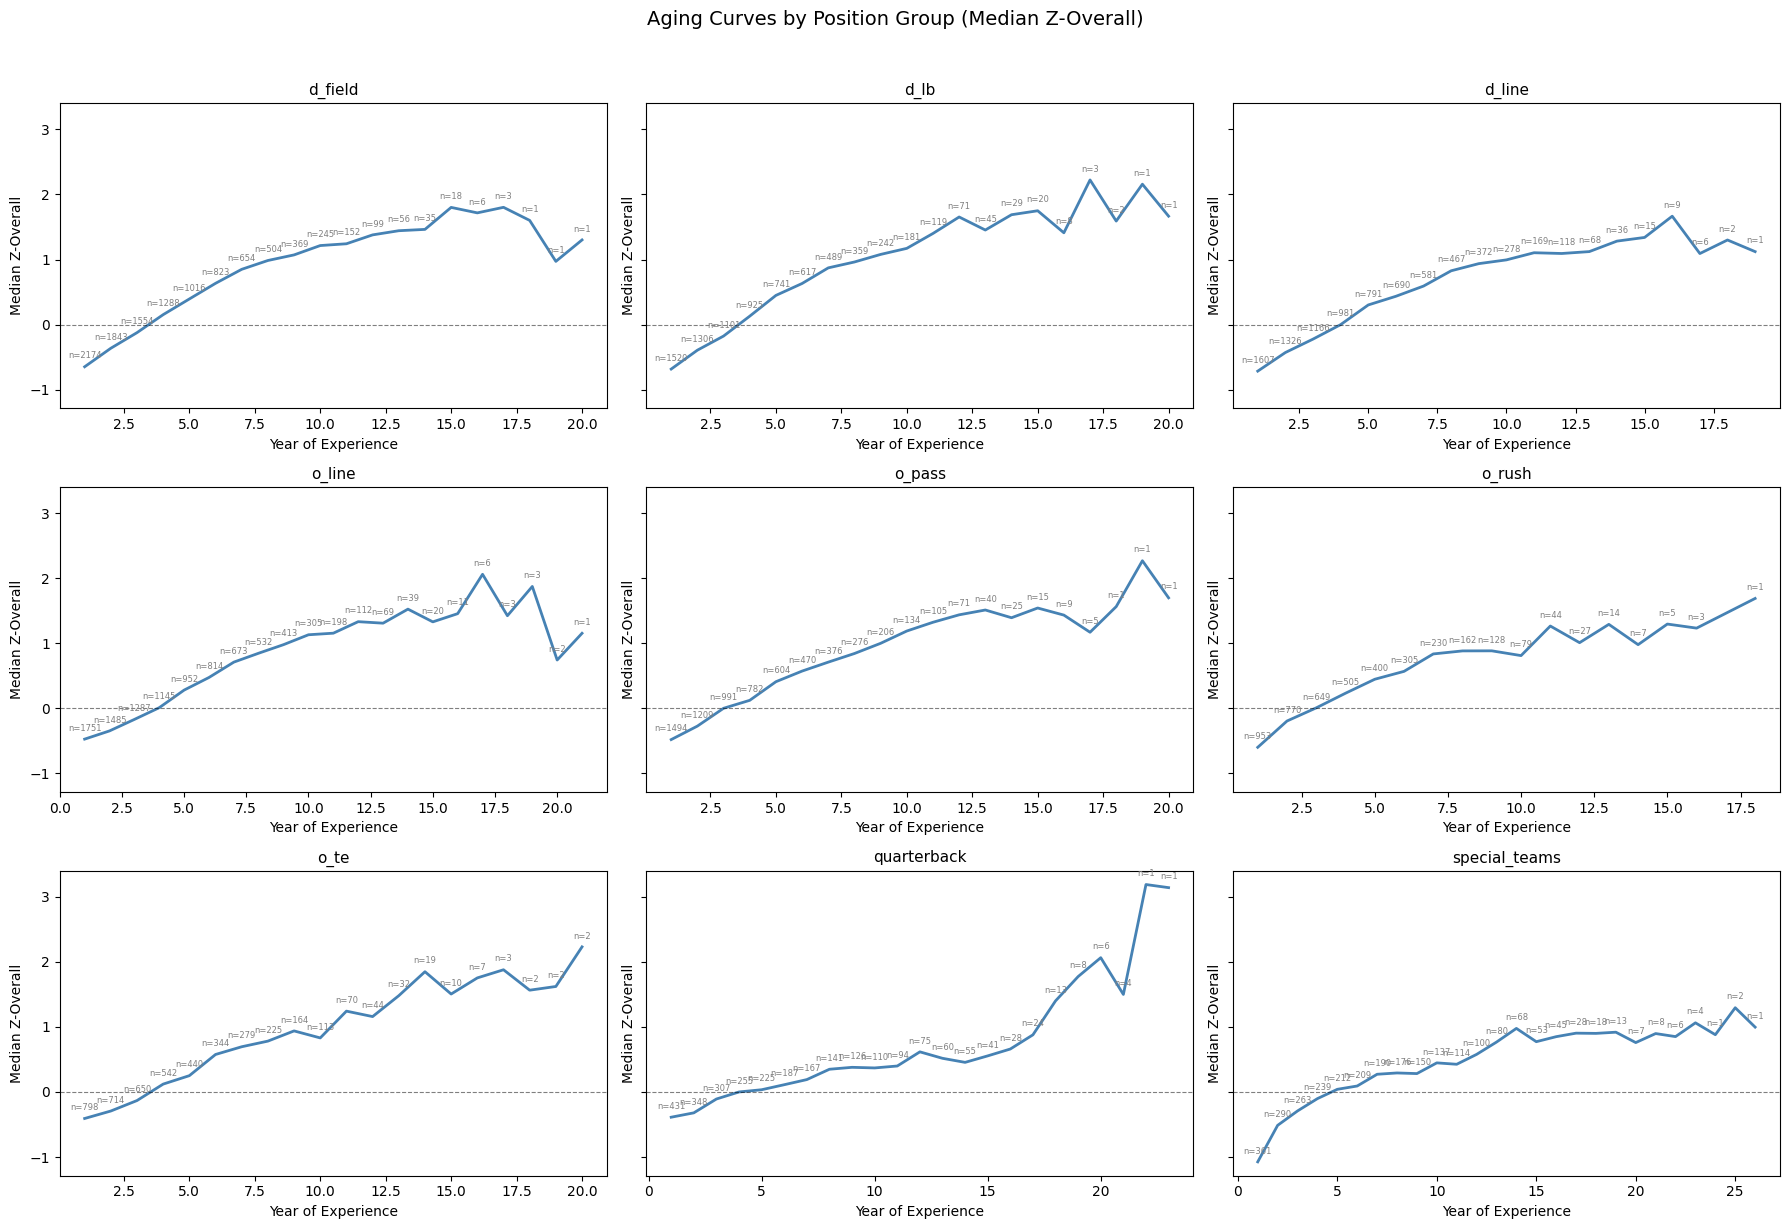

In [ ]:
groups = sorted(summary["position_group"].unique())
ncols = 3
nrows = -(-len(groups) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=True)
axes = axes.flatten()

for i, pos in enumerate(groups):
    ax = axes[i]
    subset = summary.query("position_group == @pos").sort_values("year_number")

    ax.plot(subset["year_number"], subset["median_z"], color="steelblue", linewidth=2)

    for _, row in subset.iterrows():
        ax.annotate(
            f'n={int(row["n"])}',
            xy=(row["year_number"], row["median_z"]),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            fontsize=6,
            color="gray"
        )

    ax.axhline(0, linestyle="--", color="black", linewidth=0.8, alpha=0.5)
    ax.set_title(pos, fontsize=11)
    ax.set_xlabel("Year of Experience")
    ax.set_ylabel("Median Z-Overall")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Aging Curves by Position Group (Median Z-Overall)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

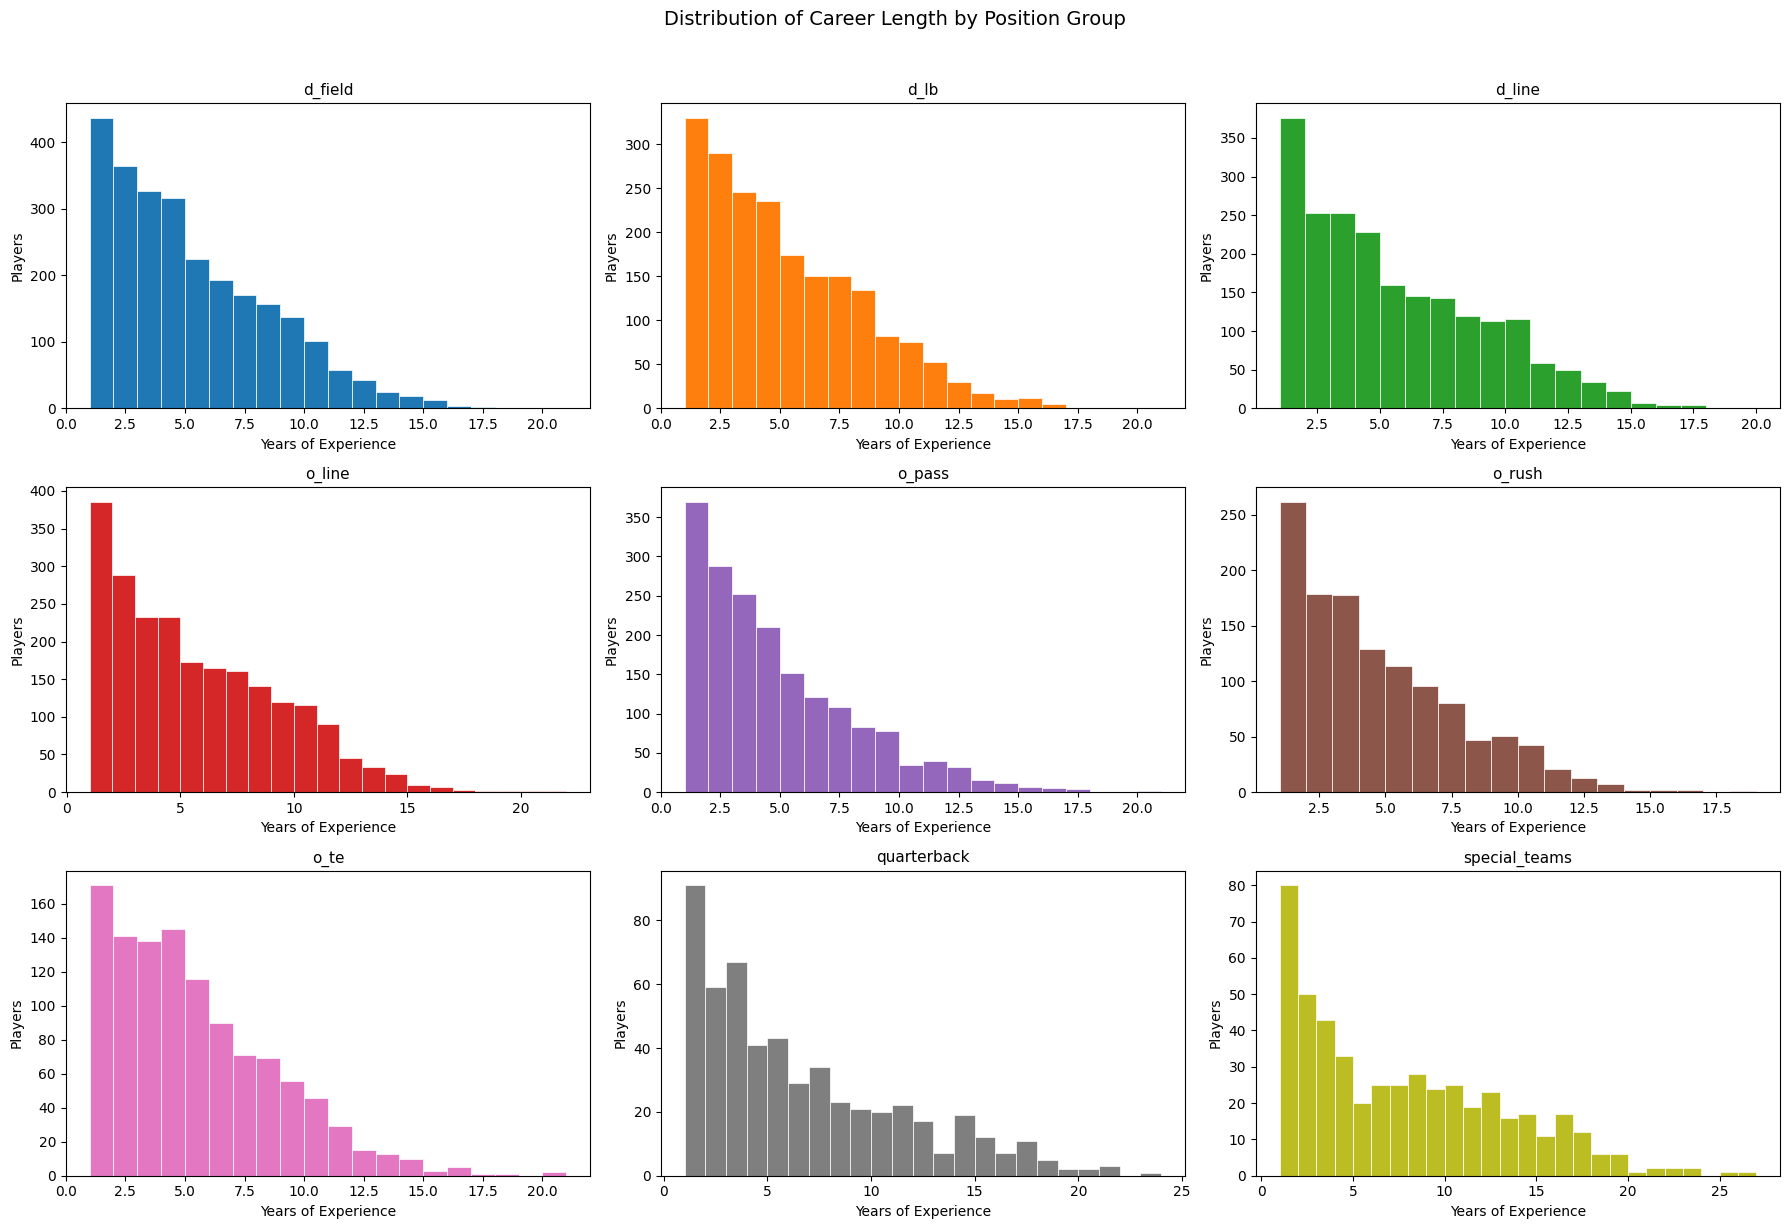

In [ ]:
# Get max year_number per player as their career length
career_lengths = (
    madden_short
    .groupby(["player_id", "position_group"])["year_number"]
    .max()
    .reset_index(name="career_length")
)

groups = sorted(career_lengths["position_group"].unique())
ncols = 3
nrows = -(-len(groups) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=False)
axes = axes.flatten()

colors = [f"C{i}" for i in range(len(groups))]

for i, pos in enumerate(groups):
    ax = axes[i]
    subset = career_lengths.query("position_group == @pos")

    ax.hist(subset["career_length"], bins=range(1, int(subset["career_length"].max()) + 2),
            color=colors[i], edgecolor="white", linewidth=0.5)

    ax.set_title(pos, fontsize=11)
    ax.set_xlabel("Years of Experience")
    ax.set_ylabel("Players")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution of Career Length by Position Group", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

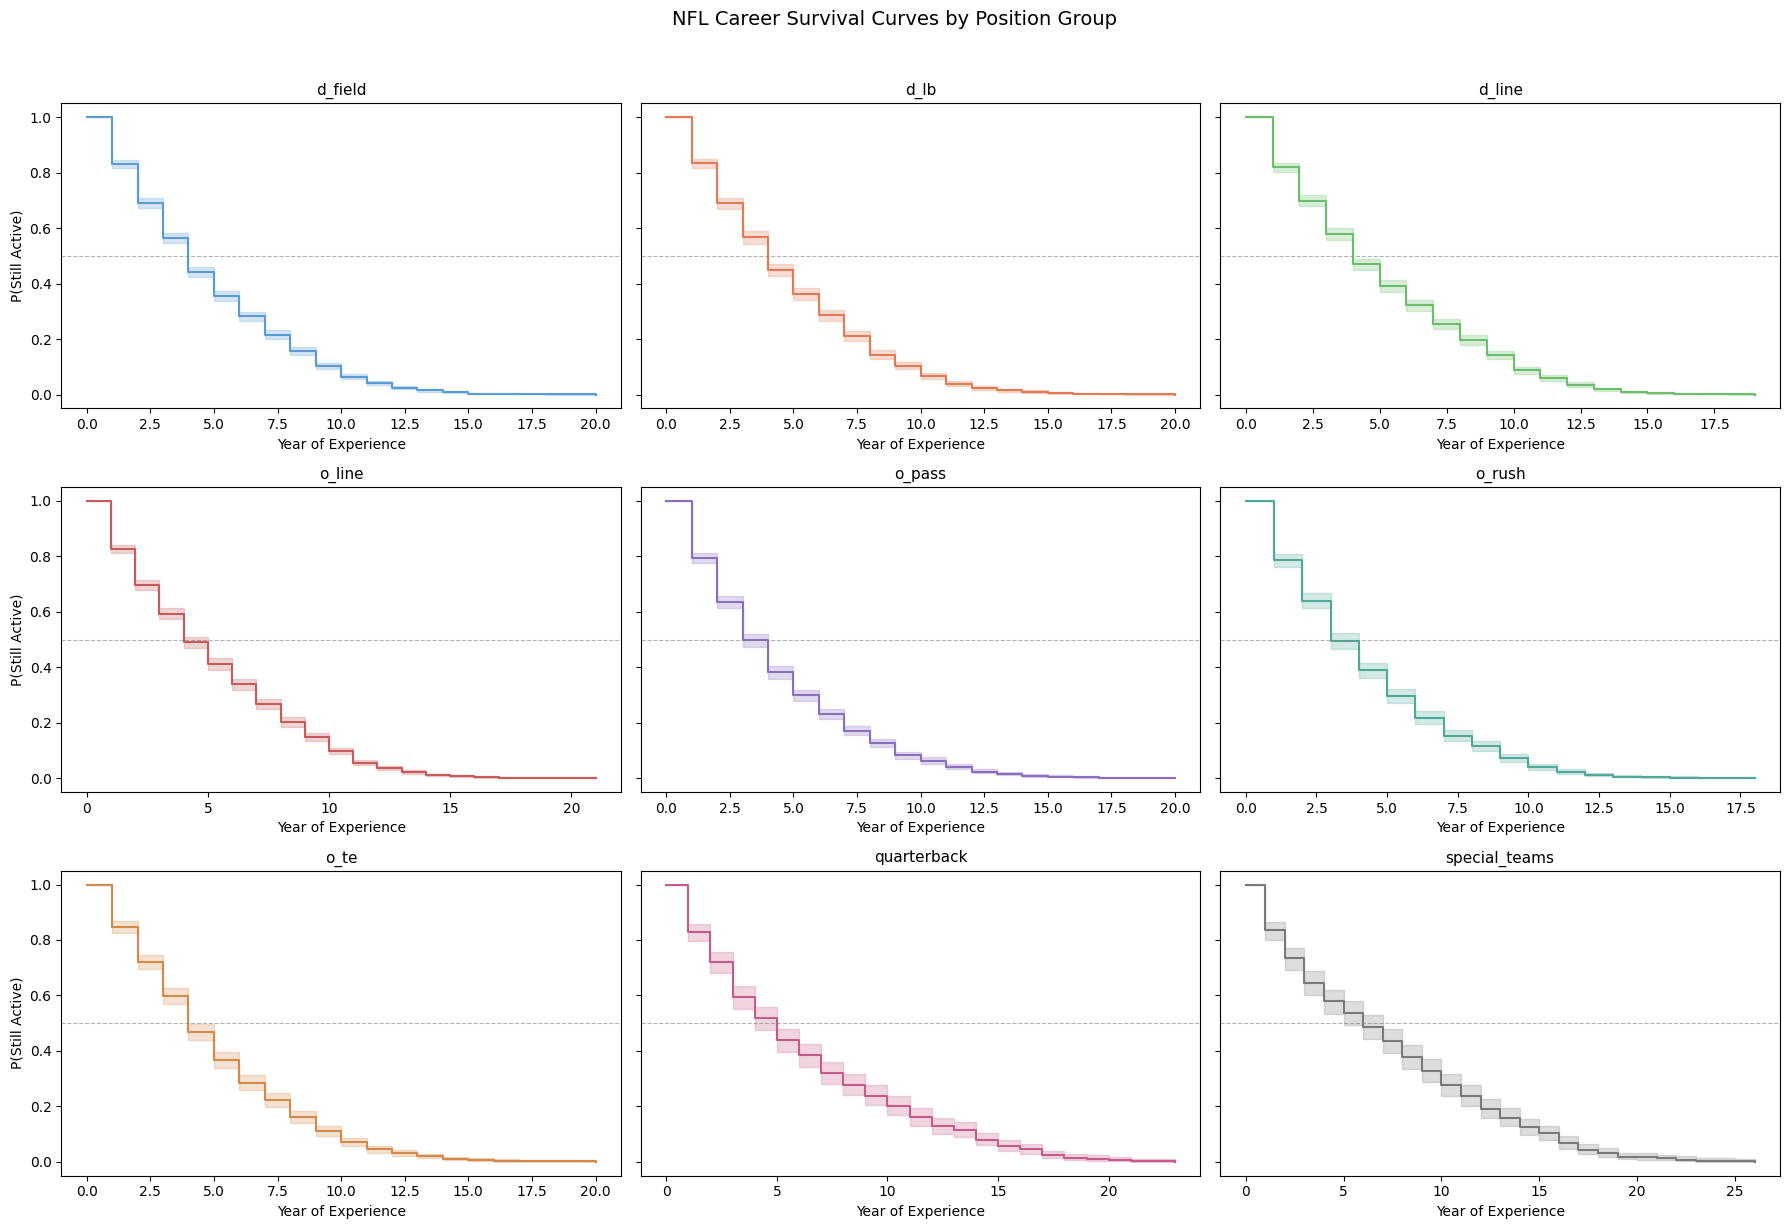

In [ ]:
from lifelines import KaplanMeierFitter

career_lengths = (
    madden_short
    .groupby(["player_id", "position_group"])["year_number"]
    .max()
    .reset_index(name="career_length")
)

groups = sorted(career_lengths["position_group"].unique())
pastel = ["#5B9BD5", "#E07B54", "#6BBF6B", "#C75B5B", "#8A6FBF", "#4FA89A", "#D4884A", "#C45B8A", "#7A7A7A"]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for i, pos in enumerate(groups):
    ax = axes[i]
    subset = career_lengths.query("position_group == @pos")

    kmf = KaplanMeierFitter()
    kmf.fit(subset["career_length"], label=pos)
    kmf.plot_survival_function(ax=ax, color=pastel[i % len(pastel)], ci_show=True)

    ax.set_xlabel("Year of Experience")
    ax.set_ylabel("P(Still Active)")
    ax.set_title(pos, fontsize=11)
    ax.legend().remove()
    ax.axhline(0.5, linestyle="--", color="gray", linewidth=0.8, alpha=0.6)

for j in range(len(groups), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("NFL Career Survival Curves by Position Group", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
summary

,position_group,year_number,mean_z,median_z,n
0,d_field,1.0,-0.519213,-0.647668,2174
1,d_field,2.0,-0.216889,-0.363020,1843
2,d_field,3.0,0.057559,-0.123183,1554
3,d_field,4.0,0.299563,0.153292,1288
4,d_field,5.0,0.500254,0.394270,1016
...,...,...,...,...,...
181,special_teams,22.0,1.002103,0.850495,6
182,special_teams,23.0,1.131052,1.062295,4
183,special_teams,24.0,0.879672,0.879672,1
184,special_teams,25.0,1.294162,1.294162,2


In [ ]:
summary_ev = summary.copy()
n_max = summary_ev.groupby("position_group")["n"].transform("max")
summary_ev["p_survive"] = summary_ev["n"] / n_max
summary_ev["ev_z"] = summary_ev["median_z"] * summary_ev["p_survive"]

peak_age = (
    summary_ev
    .loc[summary_ev.groupby("position_group")["ev_z"].idxmax()]
    [["position_group", "year_number", "median_z", "ev_z", "p_survive", "n"]]
    .sort_values("year_number")
    .reset_index(drop=True)
)

display(peak_age)

,position_group,year_number,median_z,ev_z,p_survive,n
0,o_te,6.0,0.575803,0.248216,0.431078,344
1,o_pass,6.0,0.571686,0.179848,0.314592,470
2,d_field,7.0,0.849824,0.255651,0.300828,654
3,d_lb,7.0,0.872093,0.280562,0.321711,489
4,o_rush,7.0,0.835198,0.201569,0.241343,230
5,o_line,7.0,0.709507,0.272700,0.384352,673
6,d_line,8.0,0.827276,0.240409,0.290604,467
7,quarterback,8.0,0.348957,0.114160,0.327146,141
8,special_teams,14.0,0.976476,0.183935,0.188366,68


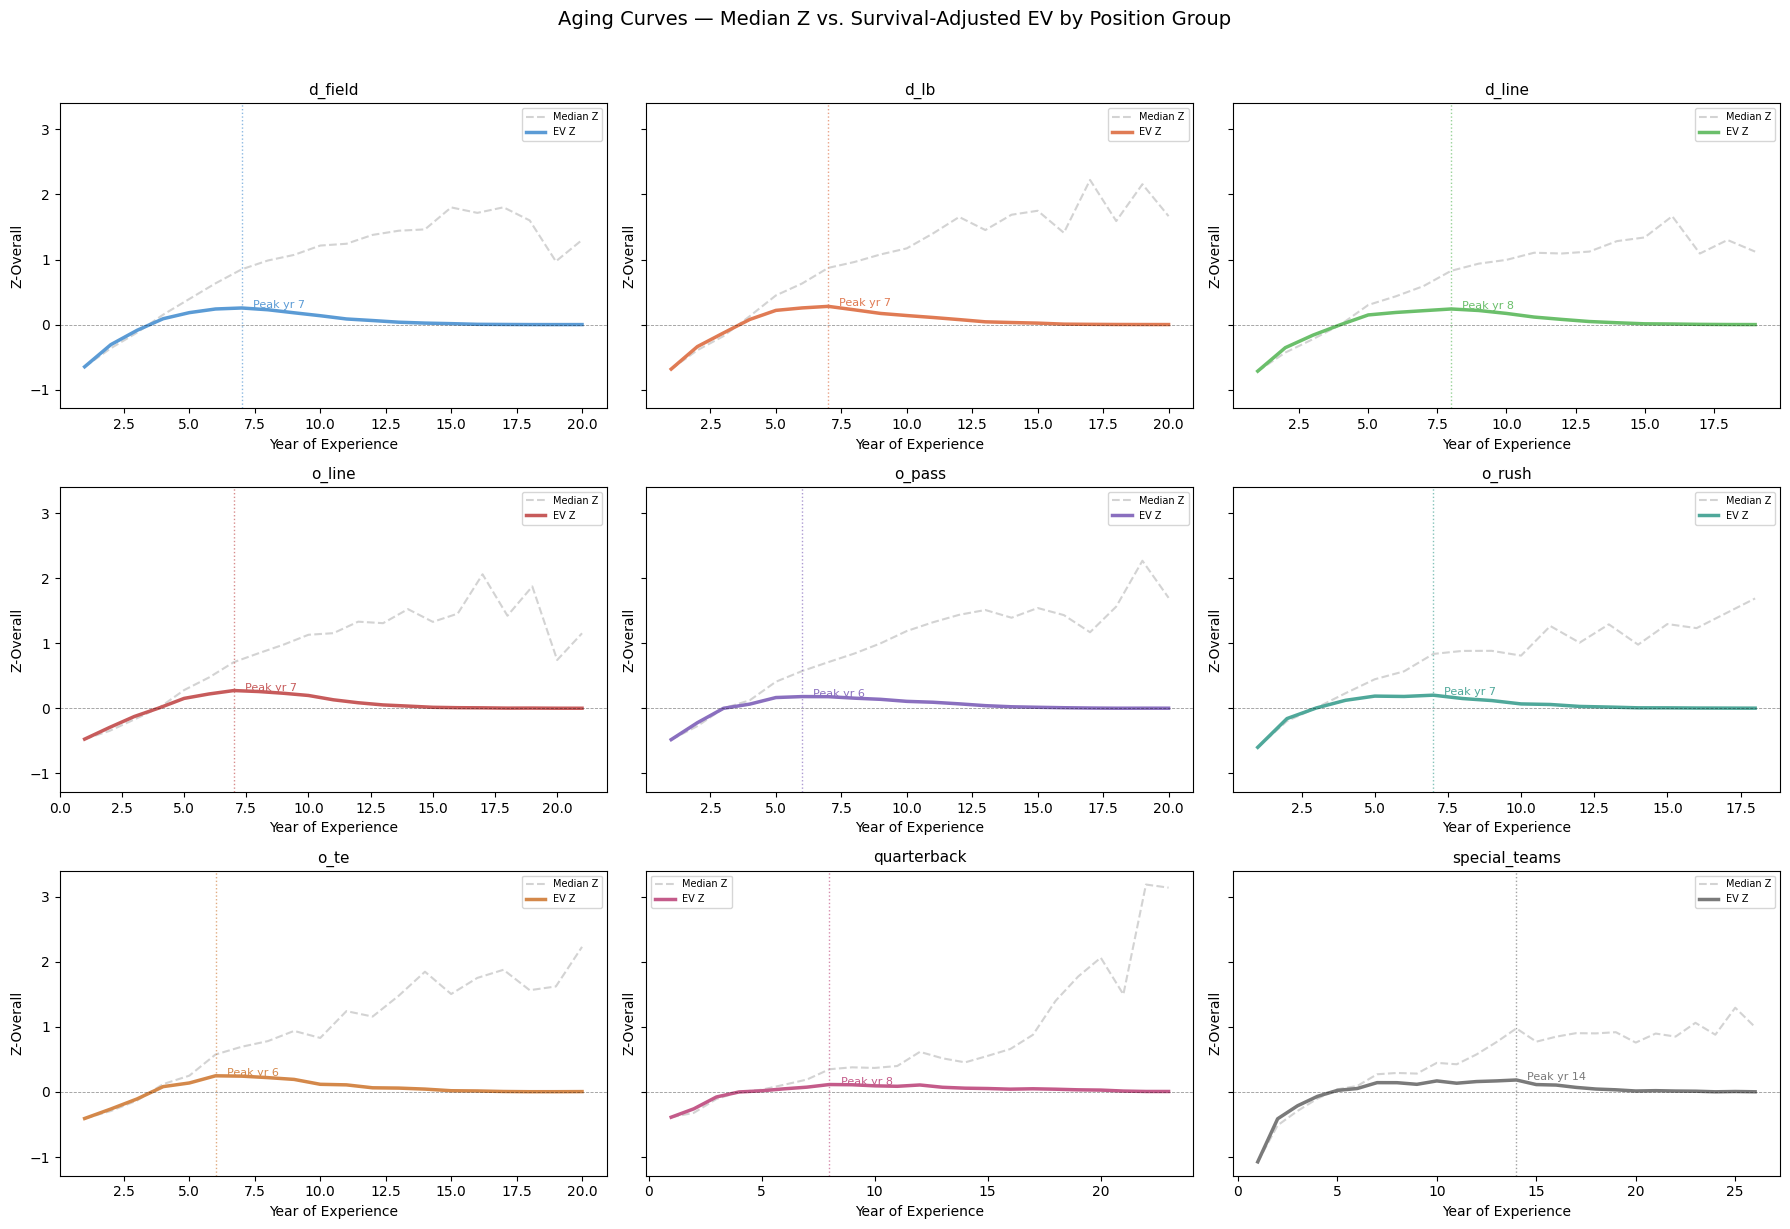

In [ ]:
groups = sorted(summary_ev["position_group"].unique())
ncols = 3
nrows = -(-len(groups) // ncols)

colors = ["#5B9BD5", "#E07B54", "#6BBF6B", "#C75B5B", "#8A6FBF",
          "#4FA89A", "#D4884A", "#C45B8A", "#7A7A7A"]

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=True)
axes = axes.flatten()

for i, pos in enumerate(groups):
    ax = axes[i]
    subset = summary_ev.query("position_group == @pos").sort_values("year_number")

    # Pull peak row directly from summary_ev instead of peak_age
    peak_row = subset.loc[subset["ev_z"].idxmax()]

    ax.plot(subset["year_number"], subset["median_z"], color="lightgray", linewidth=1.5, linestyle="--", label="Median Z")
    ax.plot(subset["year_number"], subset["ev_z"], color=colors[i], linewidth=2.5, label="EV Z")

    ax.axvline(peak_row["year_number"], color=colors[i], linewidth=1, linestyle=":", alpha=0.7)
    ax.annotate(f'Peak yr {int(peak_row["year_number"])}',
                xy=(peak_row["year_number"], peak_row["ev_z"]),
                xytext=(8, 0), textcoords="offset points",
                fontsize=8, color=colors[i])

    ax.axhline(0, linestyle="--", color="black", linewidth=0.6, alpha=0.4)
    ax.set_title(pos, fontsize=11)
    ax.set_xlabel("Year of Experience")
    ax.set_ylabel("Z-Overall")
    ax.legend(fontsize=7)

for j in range(len(groups), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Aging Curves — Median Z vs. Survival-Adjusted EV by Position Group", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Sum of the ev of players who did play plus didn't play next year.
-> try some different floor values for overalls of players that do not play.

Look at the players change the year before they left to see where.

- Can we do exepcted value for hte rest of their career?
--> translate that back to contract value perspective.



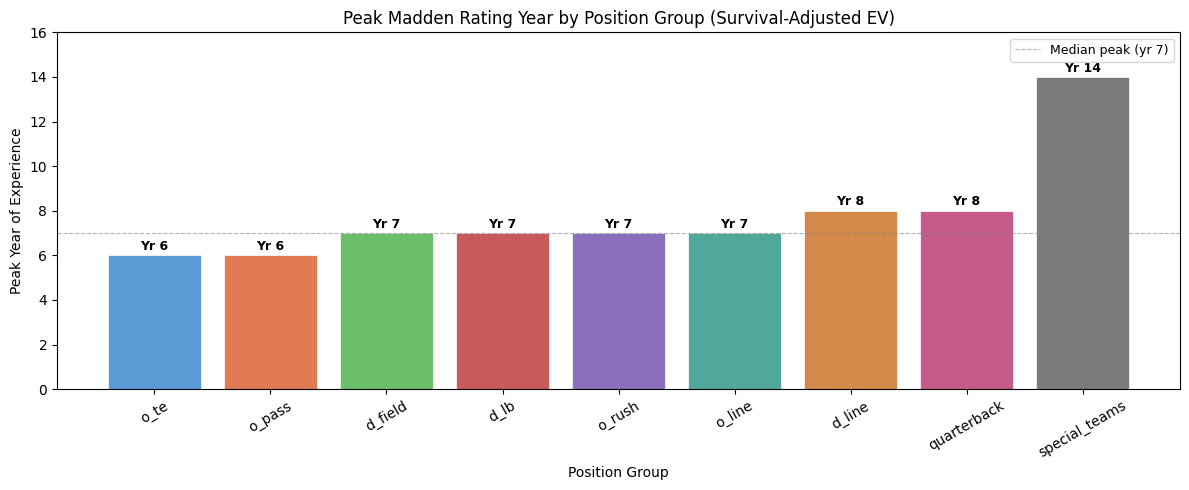

In [ ]:
peak_age = (
    summary_ev
    .loc[summary_ev.groupby("position_group")["ev_z"].idxmax()]
    [["position_group", "year_number", "ev_z", "n"]]
    .sort_values("year_number")
    .reset_index(drop=True)
)

colors = ["#5B9BD5", "#E07B54", "#6BBF6B", "#C75B5B", "#8A6FBF",
          "#4FA89A", "#D4884A", "#C45B8A", "#7A7A7A"]

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(peak_age["position_group"], peak_age["year_number"],
              color=colors[:len(peak_age)], edgecolor="white", linewidth=0.5)

for bar, (_, row) in zip(bars, peak_age.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'Yr {int(row["year_number"])}', ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("Position Group")
ax.set_ylabel("Peak Year of Experience")
ax.set_title("Peak Madden Rating Year by Position Group (Survival-Adjusted EV)")
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, peak_age["year_number"].max() + 2)
ax.axhline(peak_age["year_number"].median(), linestyle="--", color="gray", linewidth=0.8, alpha=0.6, label=f'Median peak (yr {int(peak_age["year_number"].median())})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10645/2926015176.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["position_group", "round_bucket", "year_number"])
/tmp/ipykernel_10645/2926015176.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_max = summary_by_round.groupby(["position_group", "round_bucket"])["n"].transform("max")
/tmp/ipykernel_10645/2926015176.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bucket, grp in

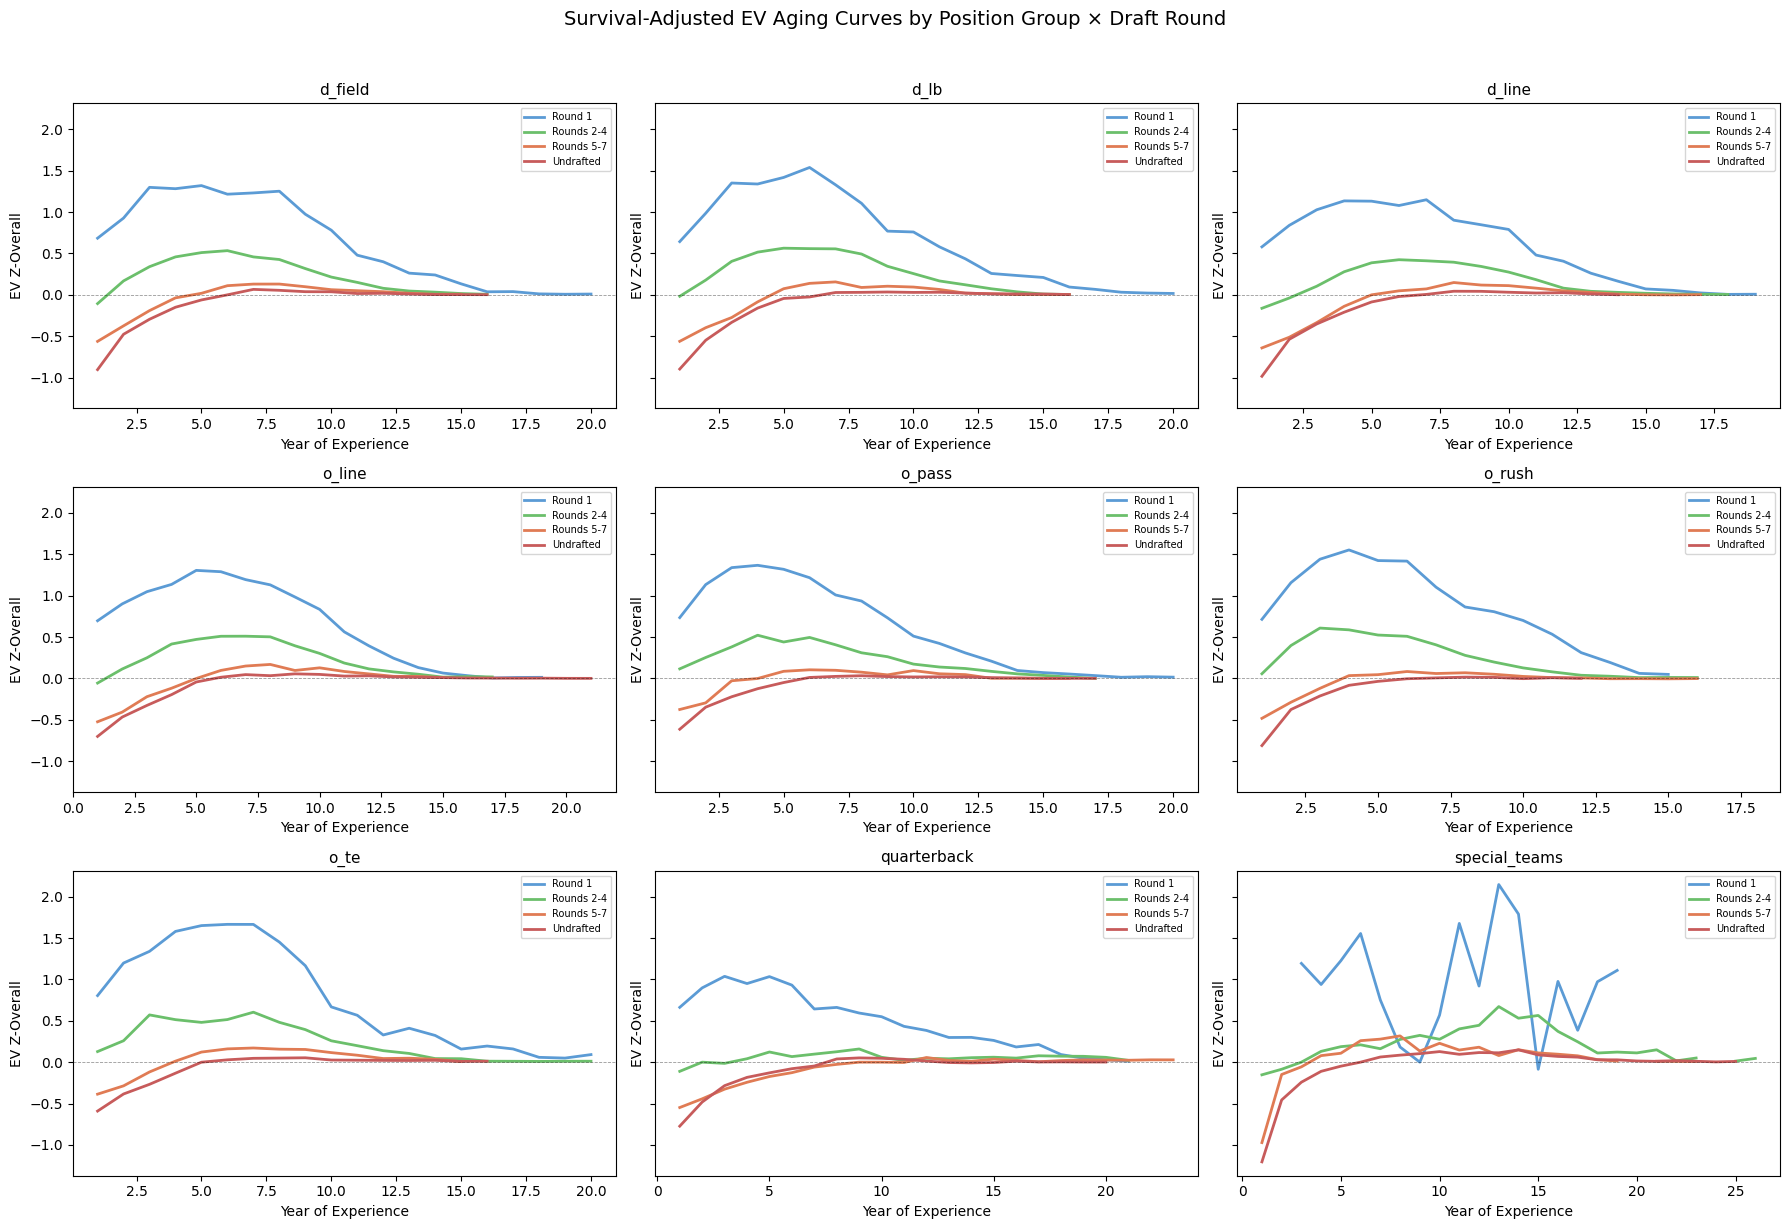

In [ ]:
madden_drafted = madden_short.merge(
    players[["gsis_id", "draft_round"]],
    left_on="player_id", right_on="gsis_id", how="left"
)

madden_drafted["round_bucket"] = pd.cut(
    madden_drafted["draft_round"],
    bins=[0, 1, 4, 7, 8],
    labels=["Round 1", "Rounds 2-4", "Rounds 5-7", "Undrafted"],
    right=True
).fillna("Undrafted")

summary_by_round = (
    madden_drafted
    .groupby(["position_group", "round_bucket", "year_number"])
    .agg(median_z=("z_overall", "median"), n=("player_id", "count"))
    .reset_index()
)

# Survival-adjust within each position × round bucket
n_max = summary_by_round.groupby(["position_group", "round_bucket"])["n"].transform("max")
summary_by_round["p_survive"] = summary_by_round["n"] / n_max
summary_by_round["ev_z"] = summary_by_round["median_z"] * summary_by_round["p_survive"]

groups = sorted(summary_by_round["position_group"].unique())
round_colors = {"Round 1": "#5B9BD5", "Rounds 2-4": "#6BBF6B", "Rounds 5-7": "#E07B54", "Undrafted": "#C75B5B"}

ncols = 3
nrows = -(-len(groups) // ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=True)
axes = axes.flatten()

for i, pos in enumerate(groups):
    ax = axes[i]
    subset = summary_by_round.query("position_group == @pos")

    for bucket, grp in subset.groupby("round_bucket"):
        grp = grp.sort_values("year_number")
        ax.plot(grp["year_number"], grp["ev_z"],
                color=round_colors[str(bucket)], linewidth=2, label=str(bucket))

    ax.axhline(0, linestyle="--", color="black", linewidth=0.6, alpha=0.4)
    ax.set_title(pos, fontsize=11)
    ax.set_xlabel("Year of Experience")
    ax.set_ylabel("EV Z-Overall")
    ax.legend(fontsize=7)

for j in range(len(groups), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Survival-Adjusted EV Aging Curves by Position Group × Draft Round", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

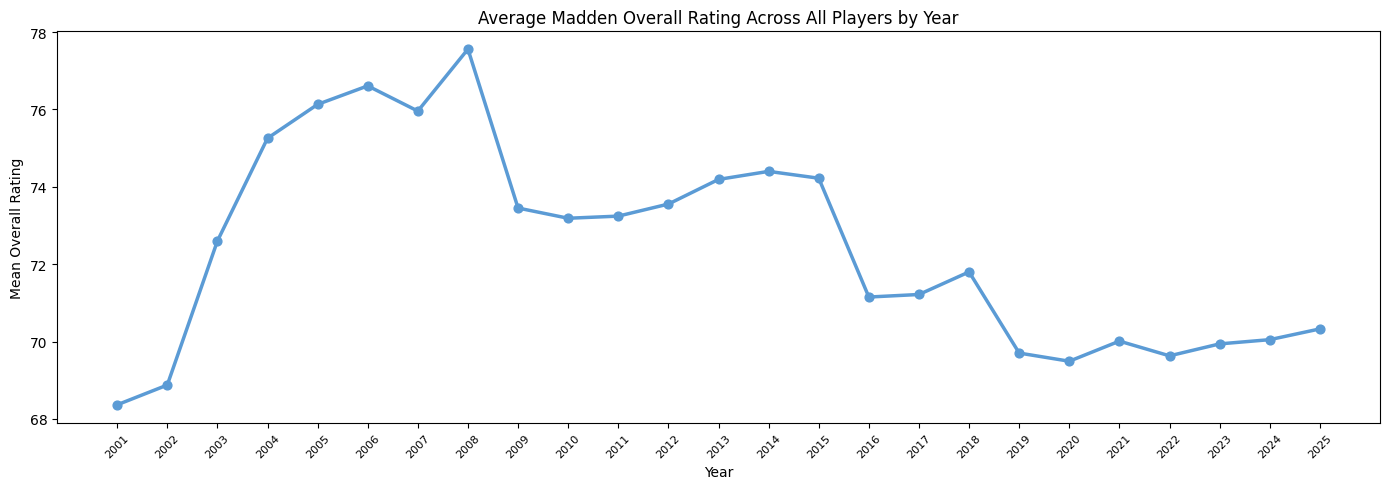

In [ ]:
yearly_overall = madden_short.groupby("year")["overallrating"].mean().reset_index(name="mean_overall")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly_overall["year"], yearly_overall["mean_overall"], color="#5B9BD5", linewidth=2.5)
ax.scatter(yearly_overall["year"], yearly_overall["mean_overall"], color="#5B9BD5", s=40, zorder=3)

ax.set_xlabel("Year")
ax.set_ylabel("Mean Overall Rating")
ax.set_title("Average Madden Overall Rating Across All Players by Year")
ax.set_xticks(yearly_overall["year"])
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

## Analysis

### Stuff

In [ ]:
madden_long.head(3)

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year
0,00-0004543,SHANEDRONETT_d_line,DronSh20,Shane Dronett,def,d_line,DL,2001,ATL,1.0,75.0,53.0,65.0,58.0,79.0,84.0,84.0,79.0,81.0,43.0,7.347195,4,11,35.306958,66.518996,11.0,20.0,20.0,20.0,16.696763,19.318944,28.0,-2.261149,-1.546120,2.340851,3.478826,22.0,6.519022,10.549796,11.996476,9.005981,8.412261,8.034401,16.0,16.0,0.483380,15.249485,17.082539,81.0,51.752871,8.673651,66.456748,21.0,24.0,0.675884,2001
1,00-0012842,JASONPETER_d_line,PeteJa20,Jason Peter,def,d_line,DL,2001,CAR,1.0,74.0,66.0,74.0,64.0,84.0,78.0,84.0,80.0,67.0,51.0,7.889415,5,7,47.836493,58.864012,10.0,21.0,21.0,21.0,18.295792,21.480056,24.0,0.980120,-0.375920,8.238861,7.495244,21.0,5.982346,9.869347,12.073328,5.724684,4.637821,9.797546,27.0,18.0,9.782409,19.028072,23.221269,72.0,54.472249,12.652961,69.286862,18.0,19.0,3.772098,2001
2,00-0009978,LEONARDLITTLE_d_line,LittLe00,Leonard Little,def,d_line,DL,2001,LAR,1.0,73.0,72.0,62.0,75.0,65.0,70.0,70.0,82.0,64.0,52.0,25.090824,8,9,51.656422,55.302556,32.0,14.0,14.0,14.0,11.934877,13.800475,24.0,19.994085,18.021897,24.959818,21.045019,40.0,8.751804,11.499611,12.645619,17.544412,14.431167,17.109987,16.0,24.0,-5.096101,32.979157,37.209780,74.0,51.286358,28.416331,72.007990,11.0,33.0,1.131921,2001


In [ ]:
madden_short.head(3)

,fullname,player_id,position_group,overallrating,year,mean_overall,median_overall,n,overall_sd,z_overall,gsis_id,display_name,rookie_season,last_season,year_number
0,Shane Dronett,00-0004543,d_line,75.0,2001,69.036,67.441,321,10.346,0.730621,00-0004543,Shane Dronett,1992.0,2002.0,10.0
1,Jason Peter,00-0012842,d_line,74.0,2001,69.036,67.441,321,10.346,0.633965,00-0012842,Jason Peter,1998.0,2001.0,4.0
2,Leonard Little,00-0009978,d_line,73.0,2001,69.036,67.441,321,10.346,0.537309,00-0009978,Leonard Little,1998.0,2009.0,4.0


### Looking at Contracts!

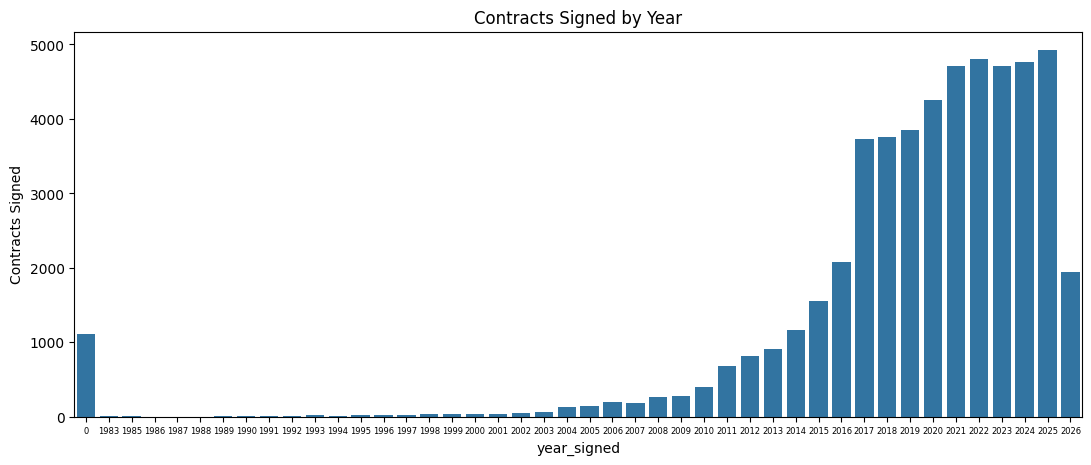

In [ ]:
contracts.groupby("year_signed").size()
plt.figure(figsize=(13, 5))
ax = sns.barplot(contracts.groupby("year_signed").size())
ax.set_ylabel("Contracts Signed")
ax.tick_params(axis='x', labelsize=6)
ax.set_title("Contracts Signed by Year")
plt.show()

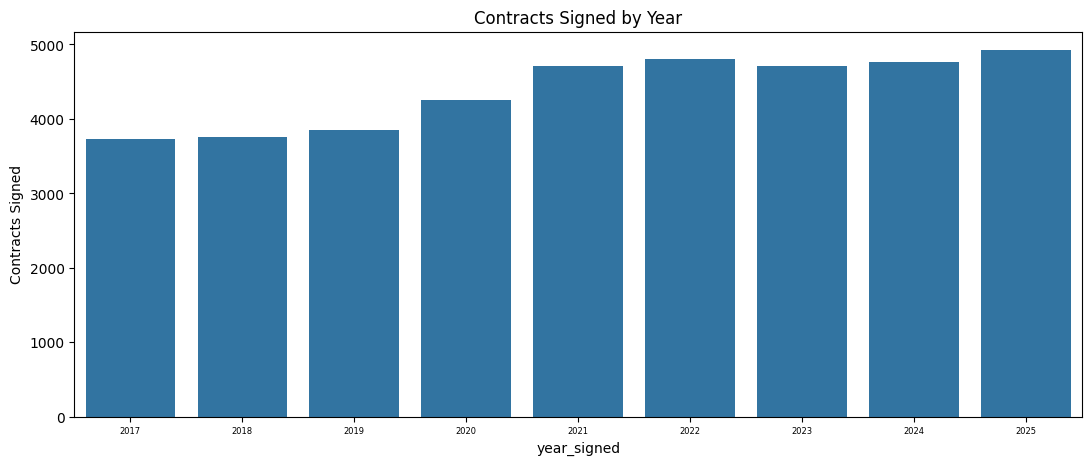

In [ ]:
mod_contracts = contracts.query("year_signed > 2016 and year_signed < 2026")
mod_contracts.groupby("year_signed").size()
plt.figure(figsize=(13, 5))
ax = sns.barplot(mod_contracts.groupby("year_signed").size())
ax.set_ylabel("Contracts Signed")
ax.tick_params(axis='x', labelsize=6)
ax.set_title("Contracts Signed by Year")
plt.show()

In [ ]:
contracts_cleaned = contracts.dropna(subset=['years', 'year_signed'])

def expand_contracts(df):
    rows = []
    for _, row in df.iterrows():
        for yr_offset in range(int(row['years'])):
            r = row.copy()
            r['season'] = int(row['year_signed']) + yr_offset
            rows.append(r)
    return pd.DataFrame(rows)

contracts_expanded = expand_contracts(contracts_cleaned)

In [ ]:
contracts_expanded = (
    contracts_expanded
    .sort_values('year_signed', ascending=False)
    .drop_duplicates(subset=['player', 'season'], keep='first')
)

In [ ]:
contracts_mod = contracts_expanded[["year_signed", "apy_cap_pct", "season", "gsis_id"]].query("season > 2016")
contracts_mod

,year_signed,apy_cap_pct,season,gsis_id
26338,2026,0.017,2026,00-0036568
26331,2026,0.018,2029,None
26331,2026,0.018,2028,None
26331,2026,0.018,2027,None
26331,2026,0.018,2026,None
...,...,...,...,...
13895,2012,0.075,2017,00-0027656
6401,2012,0.134,2018,00-0025389
50603,2012,0.030,2017,00-0027114
6401,2012,0.134,2017,00-0025389


In [ ]:
df = madden_short.query("year > 2016").merge(contracts_mod, left_on=["player_id", "year"], right_on=["gsis_id", "season"], how="left").dropna(subset = "apy_cap_pct")
df

,fullname,player_id,position_group,overallrating,year,mean_overall,median_overall,n,overall_sd,z_overall,gsis_id_x,display_name,rookie_season,last_season,year_number,year_signed,apy_cap_pct,season,gsis_id_y
0,Sharrif Floyd,00-0030574,d_line,83.000000,2017,70.598,69.0,390,8.083,1.732030,00-0030574,Sharrif Floyd,2013.0,2017.0,5.0,2013.0,0.024,2017.0,00-0030574
1,Robert Nkemdiche,00-0032761,d_line,76.000000,2017,70.598,69.0,390,8.083,0.866015,00-0032761,Robert Nkemdiche,2016.0,2021.0,2.0,2016.0,0.014,2017.0,00-0032761
2,Jacquies Smith,00-0029112,d_line,72.000000,2017,70.598,69.0,390,8.083,0.371149,00-0029112,Jacquies Smith,2012.0,2018.0,6.0,2017.0,0.004,2017.0,00-0029112
3,Jordan Hill,00-0030072,d_line,72.000000,2017,70.598,69.0,390,8.083,0.371149,00-0030072,Jordan Hill,2013.0,2017.0,5.0,2017.0,0.005,2017.0,00-0030072
4,Damontre Moore,00-0030069,d_line,70.000000,2017,70.598,69.0,390,8.083,0.123716,00-0030069,Damontre Moore,2013.0,2021.0,5.0,2017.0,0.005,2017.0,00-0030069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25571,Jake Bates,00-0039172,special_teams,76.000000,2025,73.079,74.0,136,5.916,0.338066,00-0039172,Jake Bates,2024.0,2026.0,2.0,2024.0,0.004,2025.0,00-0039172
25572,Riley Dixon,00-0032943,special_teams,76.000000,2025,73.079,74.0,136,5.916,0.338066,00-0032943,Riley Dixon,2016.0,2026.0,10.0,2025.0,0.011,2025.0,00-0032943
25573,Tory Taylor,00-0039745,special_teams,75.000000,2025,73.079,74.0,136,5.916,0.169033,00-0039745,Tory Taylor,2024.0,2026.0,2.0,2024.0,0.005,2025.0,00-0039745
25574,Blake Grupe,00-0038905,special_teams,73.000000,2025,73.079,74.0,136,5.916,-0.169033,00-0038905,Blake Grupe,2023.0,2025.0,3.0,2025.0,0.004,2025.0,00-0038905


In [ ]:
df.drop(columns = ["gsis_id_x", "gsis_id_y", "season", "year_signed"])

,fullname,player_id,position_group,overallrating,year,mean_overall,median_overall,n,overall_sd,z_overall,display_name,rookie_season,last_season,year_number,apy_cap_pct
0,Sharrif Floyd,00-0030574,d_line,83.000000,2017,70.598,69.0,390,8.083,1.732030,Sharrif Floyd,2013.0,2017.0,5.0,0.024
1,Robert Nkemdiche,00-0032761,d_line,76.000000,2017,70.598,69.0,390,8.083,0.866015,Robert Nkemdiche,2016.0,2021.0,2.0,0.014
2,Jacquies Smith,00-0029112,d_line,72.000000,2017,70.598,69.0,390,8.083,0.371149,Jacquies Smith,2012.0,2018.0,6.0,0.004
3,Jordan Hill,00-0030072,d_line,72.000000,2017,70.598,69.0,390,8.083,0.371149,Jordan Hill,2013.0,2017.0,5.0,0.005
4,Damontre Moore,00-0030069,d_line,70.000000,2017,70.598,69.0,390,8.083,0.123716,Damontre Moore,2013.0,2021.0,5.0,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25571,Jake Bates,00-0039172,special_teams,76.000000,2025,73.079,74.0,136,5.916,0.338066,Jake Bates,2024.0,2026.0,2.0,0.004
25572,Riley Dixon,00-0032943,special_teams,76.000000,2025,73.079,74.0,136,5.916,0.338066,Riley Dixon,2016.0,2026.0,10.0,0.011
25573,Tory Taylor,00-0039745,special_teams,75.000000,2025,73.079,74.0,136,5.916,0.169033,Tory Taylor,2024.0,2026.0,2.0,0.005
25574,Blake Grupe,00-0038905,special_teams,73.000000,2025,73.079,74.0,136,5.916,-0.169033,Blake Grupe,2023.0,2025.0,3.0,0.004


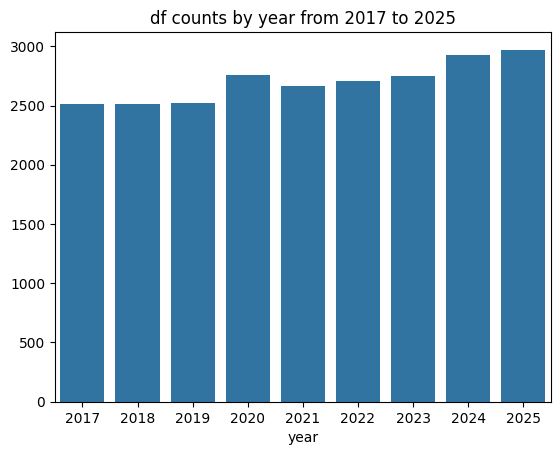

In [ ]:
ax = sns.barplot(df.groupby("year").size())
ax.set_title("df counts by year from 2017 to 2025")
plt.show()

In [ ]:
summary = df.query("apy_cap_pct > 0.005").groupby(["year", "position_group"])["apy_cap_pct"].mean().reset_index(name="mean_apy_cap_pct")
summary

,year,position_group,mean_apy_cap_pct
0,2017,d_field,0.027808
1,2017,d_lb,0.029500
2,2017,d_line,0.031910
3,2017,o_line,0.030744
4,2017,o_pass,0.032367
...,...,...,...
76,2025,o_pass,0.034500
77,2025,o_rush,0.019581
78,2025,o_te,0.024203
79,2025,quarterback,0.075623


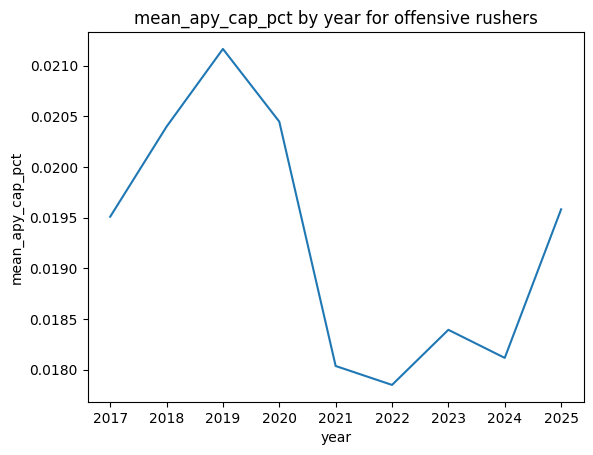

In [ ]:
sns.lineplot(data=summary.query("position_group == 'o_rush'"), x="year", y="mean_apy_cap_pct")
plt.title("mean_apy_cap_pct by year for offensive rushers")
plt.show()

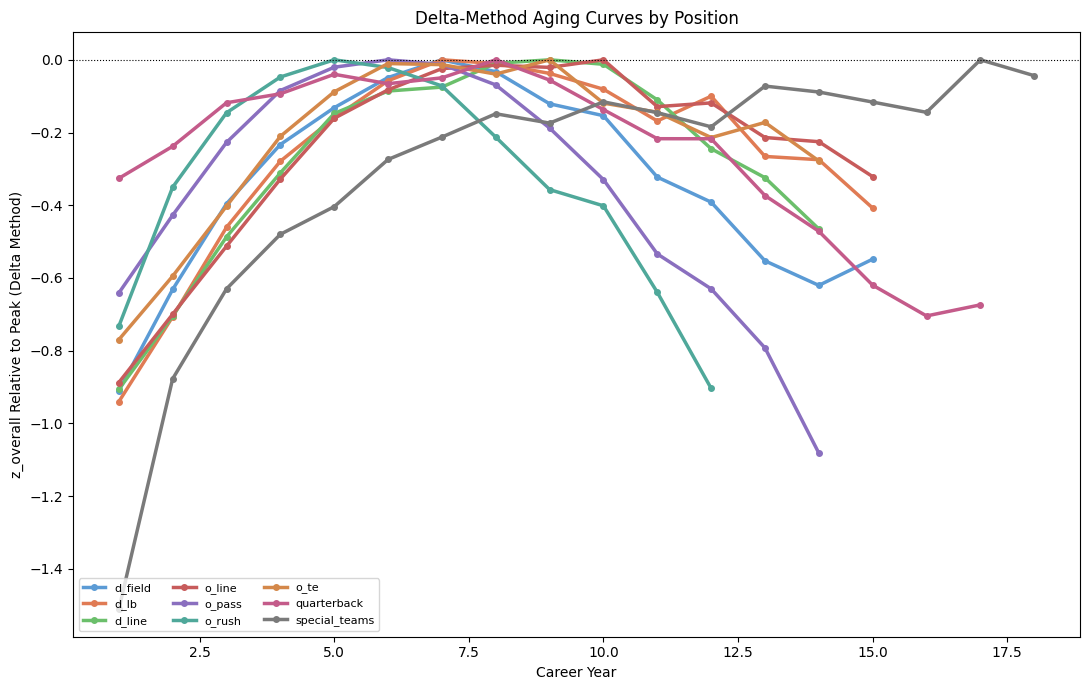

In [ ]:
def delta_method_curve(df, id_col, age_col, metric_col, min_pair_n=20):
    """
    Computes a delta-method aging curve.

    For each pair of adjacent ages, takes the average year-over-year change
    in `metric_col` among players observed at BOTH ages, then chains those
    average deltas into a single cumulative curve with the peak normalized to 0.
    """
    sub = df[[id_col, age_col, metric_col]].dropna()
    wide = sub.pivot_table(index=id_col, columns=age_col, values=metric_col, aggfunc="mean")
    ages = sorted(wide.columns)

    deltas = []
    for a_from, a_to in zip(ages[:-1], ages[1:]):
        pair = wide[[a_from, a_to]].dropna()
        n = len(pair)
        if n < min_pair_n:
            continue
        avg_delta = (pair[a_to] - pair[a_from]).mean()
        deltas.append({"age_from": a_from, "age_to": a_to, "delta": avg_delta, "n": n})

    delta_df = pd.DataFrame(deltas)
    if delta_df.empty:
        return delta_df

    # chain the deltas into one cumulative curve, starting at the first retained age
    curve_ages = [delta_df.iloc[0]["age_from"]] + delta_df["age_to"].tolist()
    cum_vals = [0.0]
    for d in delta_df["delta"]:
        cum_vals.append(cum_vals[-1] + d)

    curve = pd.DataFrame({"age": curve_ages, "cum_raw": cum_vals})
    curve["curve_value"] = curve["cum_raw"] - curve["cum_raw"].max()  # normalize peak to 0

    n_map = dict(zip(delta_df["age_to"], delta_df["n"]))
    curve["n"] = curve["age"].map(n_map)
    curve.loc[curve["age"] == curve_ages[0], "n"] = delta_df.iloc[0]["n"]

    return curve.sort_values("age").reset_index(drop=True)

position_curves = {}
for pos in sorted(madden_short["position_group"].unique()):
    sub = madden_short.query("position_group == @pos")
    curve = delta_method_curve(sub, id_col="player_id", age_col="year_number",
                                metric_col="z_overall", min_pair_n=15)
    if not curve.empty:
        position_curves[pos] = curve

fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#5B9BD5", "#E07B54", "#6BBF6B", "#C75B5B", "#8A6FBF",
          "#4FA89A", "#D4884A", "#C45B8A", "#7A7A7A"]

for i, (pos, curve) in enumerate(position_curves.items()):
    ax.plot(curve["age"], curve["curve_value"], color=colors[i % len(colors)],
            linewidth=2.5, marker="o", markersize=4, label=pos)

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Career Year")
ax.set_ylabel("z_overall Relative to Peak (Delta Method)")
ax.set_title("Delta-Method Aging Curves by Position")
ax.legend(loc="lower left", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

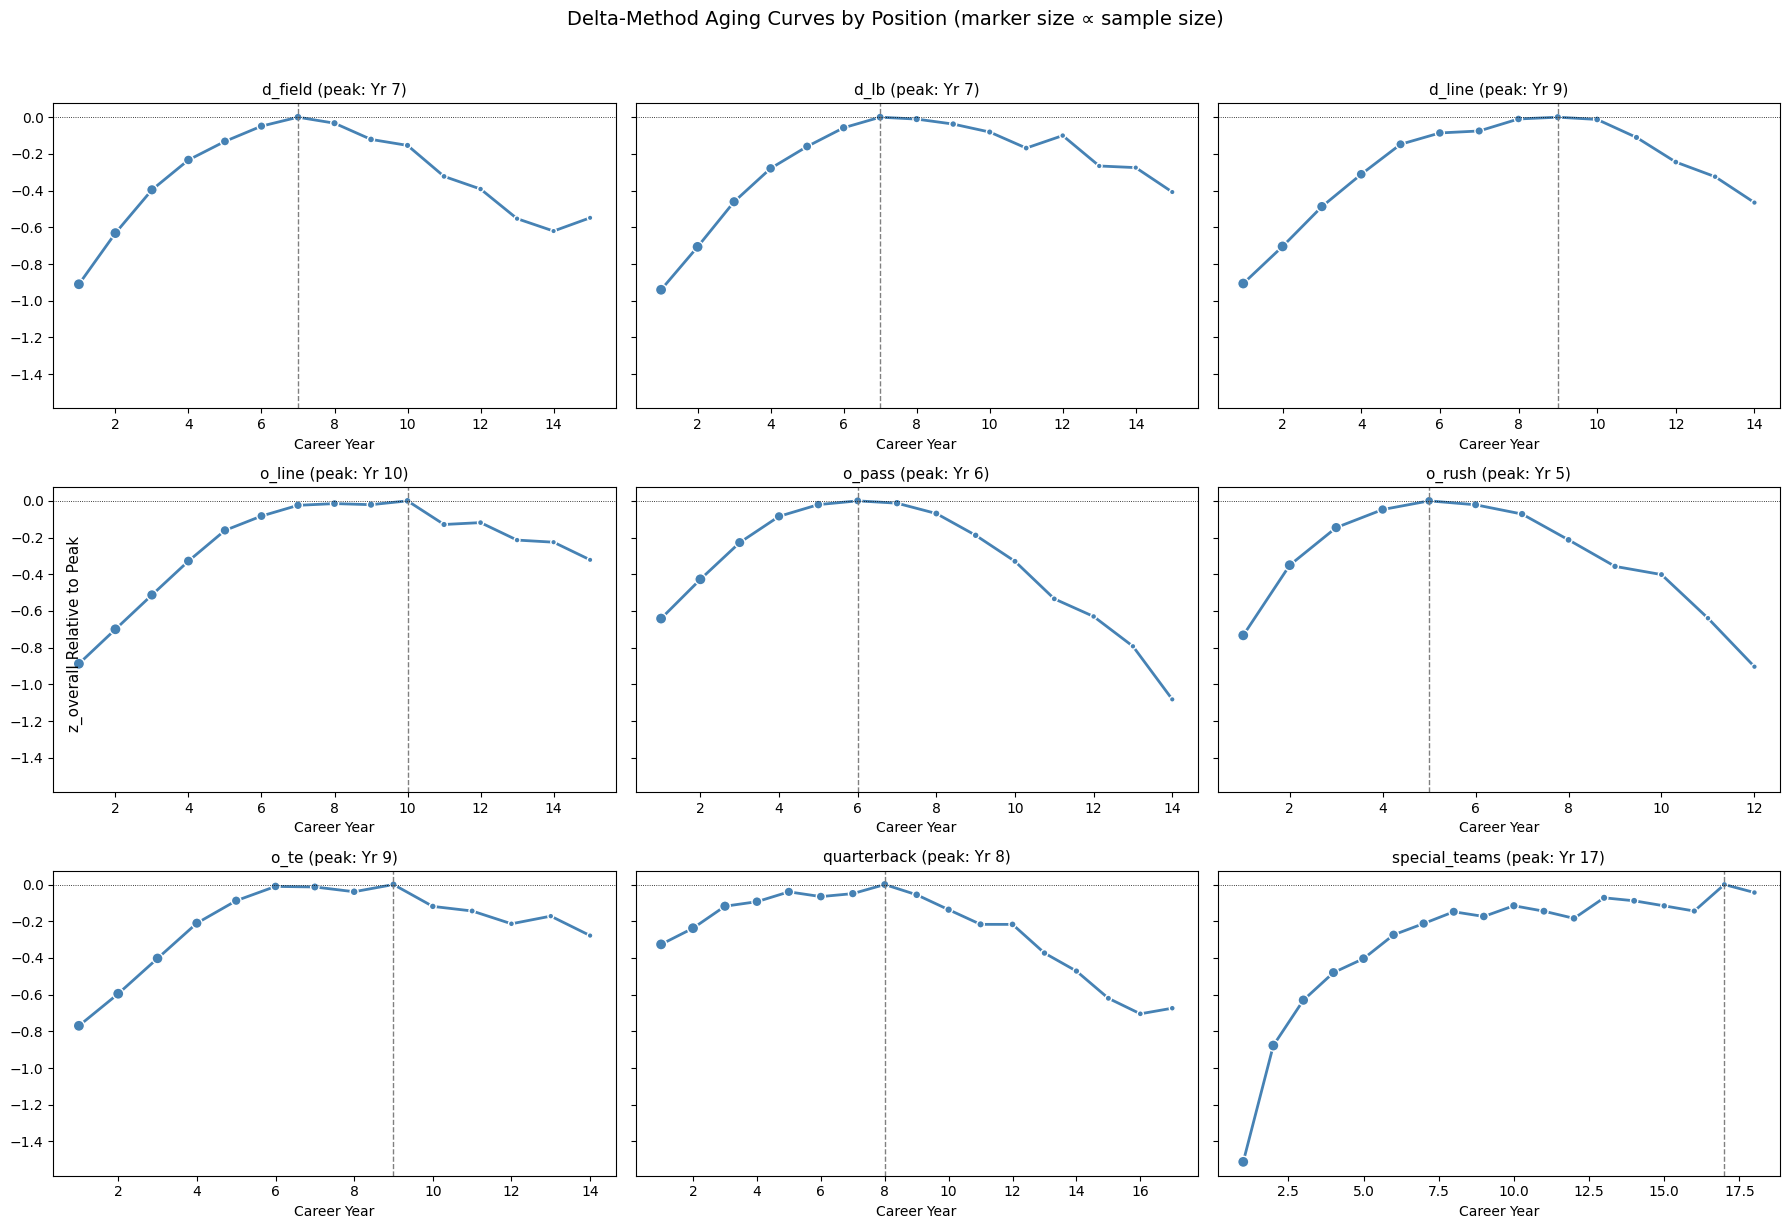

In [ ]:
groups = sorted(position_curves.keys())
ncols = 3
nrows = -(-len(groups) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=True)
axes = axes.flatten()

for i, pos in enumerate(groups):
    ax = axes[i]
    curve = position_curves[pos]
    peak_age = curve.loc[curve["curve_value"].idxmax(), "age"]
    sizes = 15 + 50 * (curve["n"] / curve["n"].max())

    ax.plot(curve["age"], curve["curve_value"], color="steelblue", linewidth=2, zorder=1)
    ax.scatter(curve["age"], curve["curve_value"], s=sizes, color="steelblue",
               edgecolor="white", zorder=2)
    ax.axvline(peak_age, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax.set_title(f"{pos} (peak: Yr {int(peak_age)})", fontsize=11)
    ax.set_xlabel("Career Year")

for j in range(len(groups), len(axes)):
    fig.delaxes(axes[j])

fig.text(0.04, 0.5, "z_overall Relative to Peak", va="center", rotation="vertical", fontsize=11)
plt.suptitle("Delta-Method Aging Curves by Position (marker size ∝ sample size)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

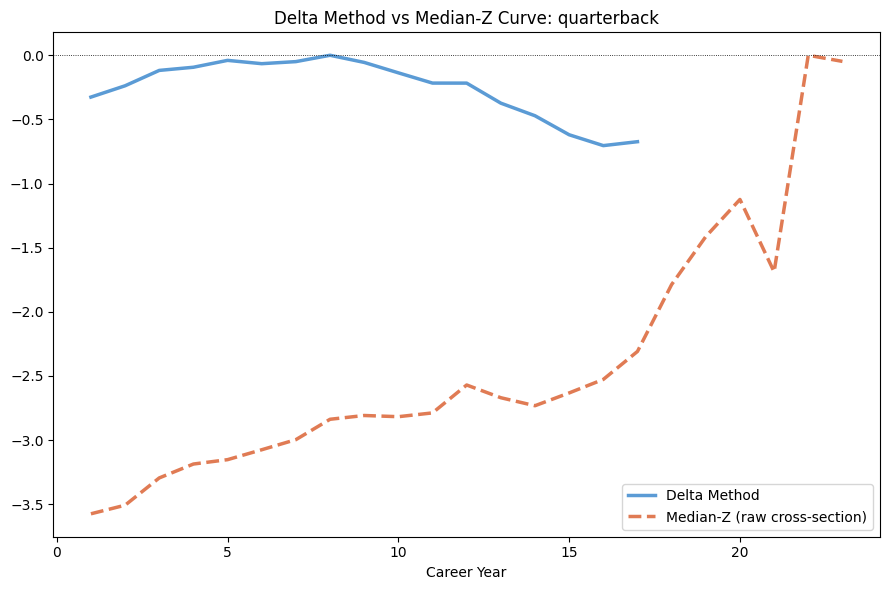

In [ ]:
pos_to_check = "quarterback"  # swap to whatever's in your position_group values
fig, ax = plt.subplots(figsize=(9, 6))

dm = position_curves[pos_to_check]
ax.plot(dm["age"], dm["curve_value"], color="#5B9BD5", linewidth=2.5, label="Delta Method")

med = summary_ev.query("position_group == @pos_to_check").sort_values("year_number")
med_norm = med["median_z"] - med["median_z"].max()
ax.plot(med["year_number"], med_norm, color="#E07B54", linewidth=2.5, linestyle="--", label="Median-Z (raw cross-section)")

ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title(f"Delta Method vs Median-Z Curve: {pos_to_check}")
ax.set_xlabel("Career Year")
ax.legend()
plt.tight_layout()
plt.show()

#### Trying to do percentile bands

In [ ]:
def percentile_bands(df, group_col, age_col, metric_col, min_n=15,
                      percentiles=(0.10, 0.25, 0.50, 0.75, 0.90)):
    bands = (
        df.groupby([group_col, age_col])[metric_col]
        .agg(
            n="count",
            p10=lambda x: x.quantile(percentiles[0]),
            p25=lambda x: x.quantile(percentiles[1]),
            p50=lambda x: x.quantile(percentiles[2]),
            p75=lambda x: x.quantile(percentiles[3]),
            p90=lambda x: x.quantile(percentiles[4]),
        )
        .reset_index()
    )
    return bands.query("n >= @min_n").sort_values([group_col, age_col])

bands = percentile_bands(madden_short, "position_group", "year_number", "z_overall", min_n=15)

In [ ]:
def delta_method_percentile_bands(df, id_col, age_col, metric_col, min_pair_n=15,
                                    percentiles=(0.10, 0.25, 0.50, 0.75, 0.90)):
    """
    Delta-method percentile bands: at each adjacent age pair, compute the
    distribution (not just the mean) of year-over-year change among players
    observed at BOTH ages. Chain each percentile's deltas separately into
    its own cumulative curve. This avoids re-pooling the cross-section at
    each age, which is what causes the survivorship-driven monotonic climb.
    """
    sub = df[[id_col, age_col, metric_col]].dropna()
    wide = sub.pivot_table(index=id_col, columns=age_col, values=metric_col, aggfunc="mean")
    ages = sorted(wide.columns)

    rows = []
    for a_from, a_to in zip(ages[:-1], ages[1:]):
        pair = wide[[a_from, a_to]].dropna()
        n = len(pair)
        if n < min_pair_n:
            continue
        deltas = pair[a_to] - pair[a_from]
        row = {"age_from": a_from, "age_to": a_to, "n": n}
        for p in percentiles:
            row[f"delta_p{int(p*100)}"] = deltas.quantile(p)
        rows.append(row)

    delta_df = pd.DataFrame(rows)
    if delta_df.empty:
        return delta_df

    curve_ages = [delta_df.iloc[0]["age_from"]] + delta_df["age_to"].tolist()
    curve = pd.DataFrame({"age": curve_ages})
    curve["n"] = [delta_df.iloc[0]["n"]] + delta_df["n"].tolist()

    for p in percentiles:
        col = f"delta_p{int(p*100)}"
        cum = [0.0]
        for d in delta_df[col]:
            cum.append(cum[-1] + d)
        curve[f"p{int(p*100)}"] = cum

    # normalize so the median curve's peak sits at 0
    peak_offset = curve["p50"].max()
    for p in percentiles:
        curve[f"p{int(p*100)}"] -= peak_offset

    return curve.sort_values("age").reset_index(drop=True)

In [ ]:
position_bands = {}
for pos in sorted(madden_short["position_group"].unique()):
    sub = madden_short.query("position_group == @pos")
    c = delta_method_percentile_bands(sub, id_col="player_id", age_col="year_number",
                                       metric_col="z_overall", min_pair_n=15)
    if not c.empty:
        position_bands[pos] = c

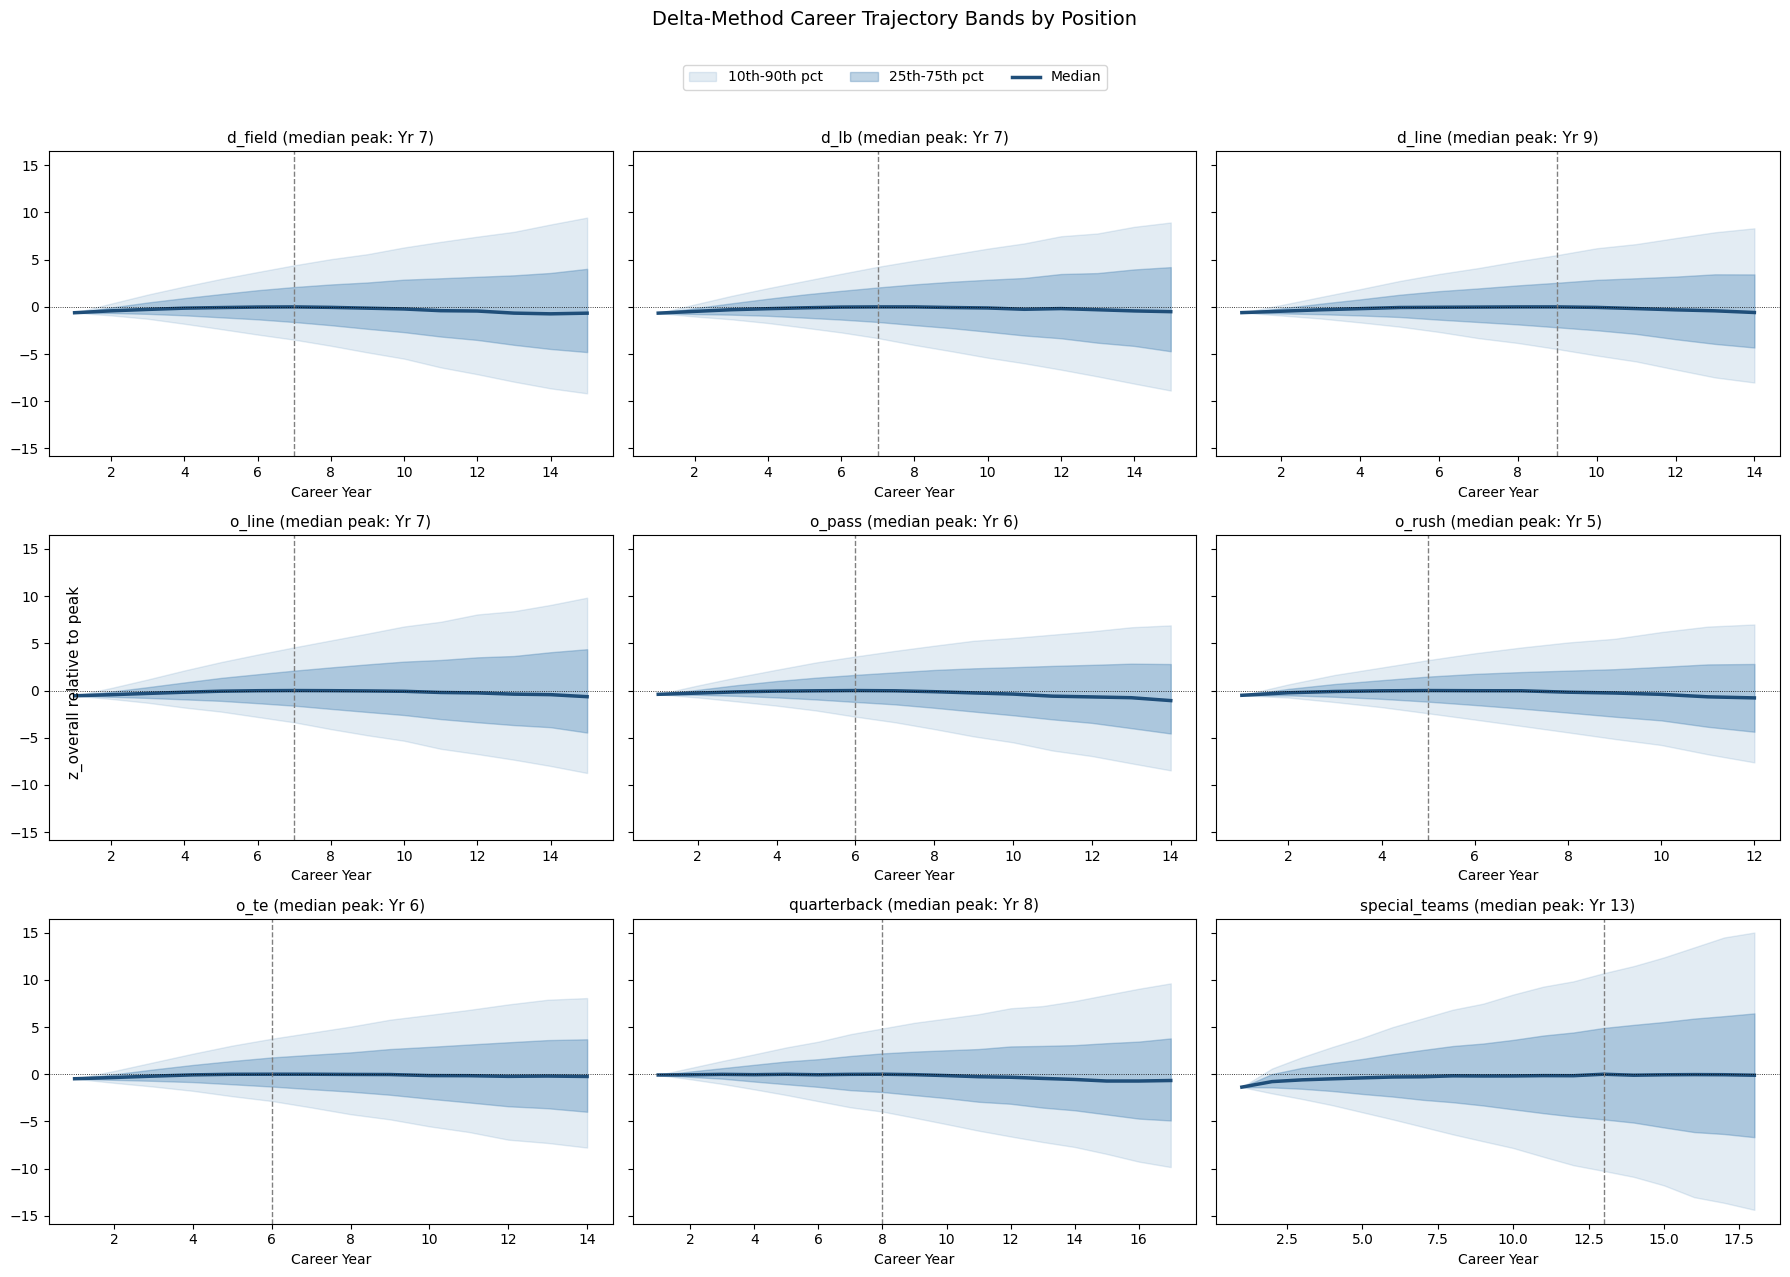

In [ ]:
groups = sorted(position_bands.keys())
ncols = 3
nrows = -(-len(groups) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=True)
axes = axes.flatten()

for i, pos in enumerate(groups):
    ax = axes[i]
    c = position_bands[pos]

    ax.fill_between(c["age"], c["p10"], c["p90"], color="steelblue", alpha=0.15, label="10th-90th pct")
    ax.fill_between(c["age"], c["p25"], c["p75"], color="steelblue", alpha=0.35, label="25th-75th pct")
    ax.plot(c["age"], c["p50"], color="#1f4e79", linewidth=2.5, label="Median")

    peak_yr = c.loc[c["p50"].idxmax(), "age"]
    ax.axvline(peak_yr, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax.set_title(f"{pos} (median peak: Yr {int(peak_yr)})", fontsize=11)
    ax.set_xlabel("Career Year")

for j in range(len(groups), len(axes)):
    fig.delaxes(axes[j])

fig.text(0.04, 0.5, "z_overall relative to peak", va="center", rotation="vertical", fontsize=11)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=10)
plt.suptitle("Delta-Method Career Trajectory Bands by Position", y=1.06, fontsize=14)
plt.tight_layout()
plt.show()

#### Trying again to do percentile bands

In [ ]:
def career_change_bands(df, id_col, age_col, metric_col, min_n=15,
                         percentiles=(0.10, 0.25, 0.50, 0.75, 0.90)):
    """
    Anchors each player's trajectory to their own debut-season value, then
    takes cross-sectional percentiles of "change since debut" at each career
    year. This avoids the invalid "sum of marginal quantiles" error from
    chaining percentile-of-delta directly, while still avoiding the raw
    cross-sectional bias of plotting levels (since every player starts at 0
    by construction, comparing players to themselves rather than to each other).
    """
    sub = df[[id_col, age_col, metric_col]].dropna().sort_values([id_col, age_col])

    anchor = sub.groupby(id_col)[metric_col].first()
    sub = sub.merge(anchor.rename("anchor"), left_on=id_col, right_index=True)
    sub["change_since_debut"] = sub[metric_col] - sub["anchor"]

    rows = []
    for age, g in sub.groupby(age_col):
        if len(g) < min_n:
            continue
        row = {"age": age, "n": len(g)}
        for p in percentiles:
            row[f"p{int(p*100)}"] = g["change_since_debut"].quantile(p)
        rows.append(row)

    return pd.DataFrame(rows).sort_values("age").reset_index(drop=True)

In [ ]:
position_bands2 = {}
for pos in sorted(madden_short["position_group"].unique()):
    sub = madden_short.query("position_group == @pos")
    b = career_change_bands(sub, id_col="player_id", age_col="year_number",
                             metric_col="z_overall", min_n=15)
    if not b.empty:
        position_bands2[pos] = b

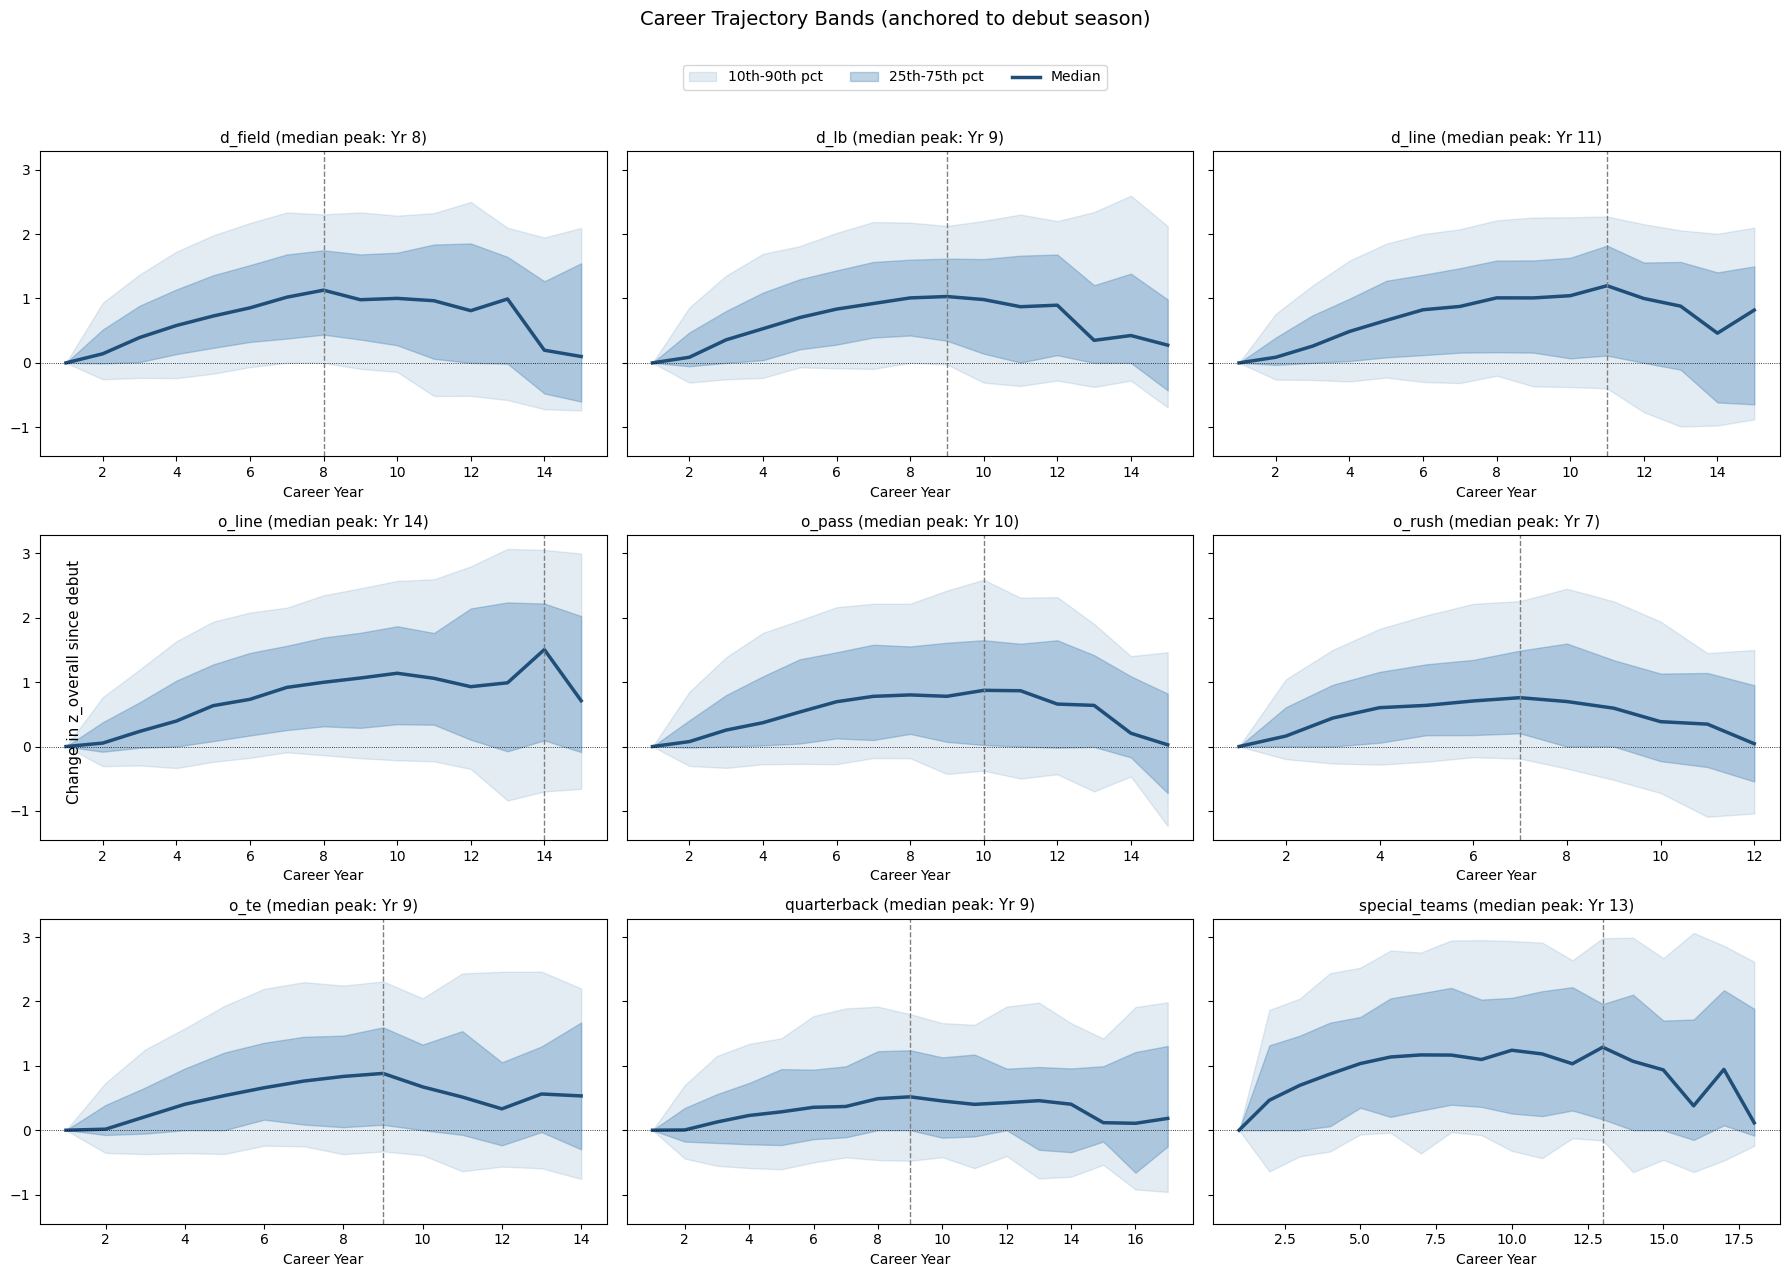

In [ ]:
groups = sorted(position_bands2.keys())
ncols = 3
nrows = -(-len(groups) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=True)
axes = axes.flatten()

for i, pos in enumerate(groups):
    ax = axes[i]
    b = position_bands2[pos]

    ax.fill_between(b["age"], b["p10"], b["p90"], color="steelblue", alpha=0.15, label="10th-90th pct")
    ax.fill_between(b["age"], b["p25"], b["p75"], color="steelblue", alpha=0.35, label="25th-75th pct")
    ax.plot(b["age"], b["p50"], color="#1f4e79", linewidth=2.5, label="Median")

    peak_yr = b.loc[b["p50"].idxmax(), "age"]
    ax.axvline(peak_yr, color="gray", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax.set_title(f"{pos} (median peak: Yr {int(peak_yr)})", fontsize=11)
    ax.set_xlabel("Career Year")

for j in range(len(groups), len(axes)):
    fig.delaxes(axes[j])

fig.text(0.04, 0.5, "Change in z_overall since debut", va="center", rotation="vertical", fontsize=11)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=10)
plt.suptitle("Career Trajectory Bands (anchored to debut season)", y=1.06, fontsize=14)
plt.tight_layout()
plt.show()

#### Delta method with apy_cap_pct


In [ ]:
pay_curves = {}
for pos in sorted(df["position_group"].unique()):
    sub = df.query("position_group == @pos")
    curve = delta_method_curve(sub, id_col="player_id", age_col="year_number",
                                metric_col="apy_cap_pct", min_pair_n=10)  # lower n: contracts are sparser
    if not curve.empty:
        pay_curves[pos] = curve

In [ ]:
def delta_pay_curve(df, id_col, age_col, metric_col, min_pair_n=10):
    sub = df[[id_col, age_col, metric_col]].dropna()
    wide = sub.pivot_table(index=id_col, columns=age_col, values=metric_col, aggfunc="mean")
    ages = sorted(wide.columns)

    deltas = []
    for a_from, a_to in zip(ages[:-1], ages[1:]):
        pair = wide[[a_from, a_to]].dropna()
        if len(pair) < min_pair_n:
            continue
        deltas.append({"age_to": a_to, "delta": (pair[a_to] - pair[a_from]).mean(), "n": len(pair)})

    delta_df = pd.DataFrame(deltas)
    if delta_df.empty:
        return delta_df

    # anchor to the actual mean cap% at the first retained debut age (not normalized to 0)
    start_age = ages[0]
    baseline = wide[start_age].dropna().mean()

    curve_ages = [start_age] + delta_df["age_to"].tolist()
    cum = [baseline]
    for d in delta_df["delta"]:
        cum.append(cum[-1] + d)

    curve = pd.DataFrame({"age": curve_ages, "cap_pct": cum})
    curve["n"] = [len(wide[start_age].dropna())] + delta_df["n"].tolist()
    return curve.sort_values("age").reset_index(drop=True)

pay_curves = {}
for pos in sorted(df["position_group"].unique()):
    sub = df.query("position_group == @pos")
    c = delta_pay_curve(sub, id_col="player_id", age_col="year_number", metric_col="apy_cap_pct", min_pair_n=10)
    if not c.empty:
        pay_curves[pos] = c

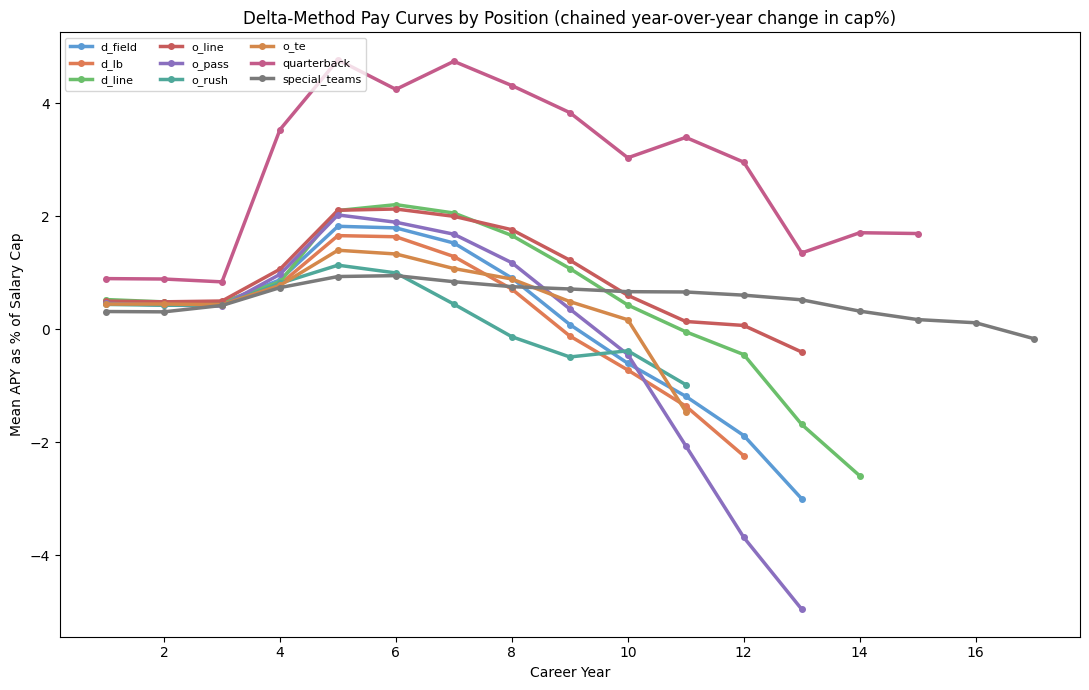

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#5B9BD5", "#E07B54", "#6BBF6B", "#C75B5B", "#8A6FBF",
          "#4FA89A", "#D4884A", "#C45B8A", "#7A7A7A"]

for i, (pos, c) in enumerate(pay_curves.items()):
    ax.plot(c["age"], c["cap_pct"] * 100, color=colors[i % len(colors)],
            linewidth=2.5, marker="o", markersize=4, label=pos)

ax.set_xlabel("Career Year")
ax.set_ylabel("Mean APY as % of Salary Cap")
ax.set_title("Delta-Method Pay Curves by Position (chained year-over-year change in cap%)")
ax.legend(loc="upper left", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

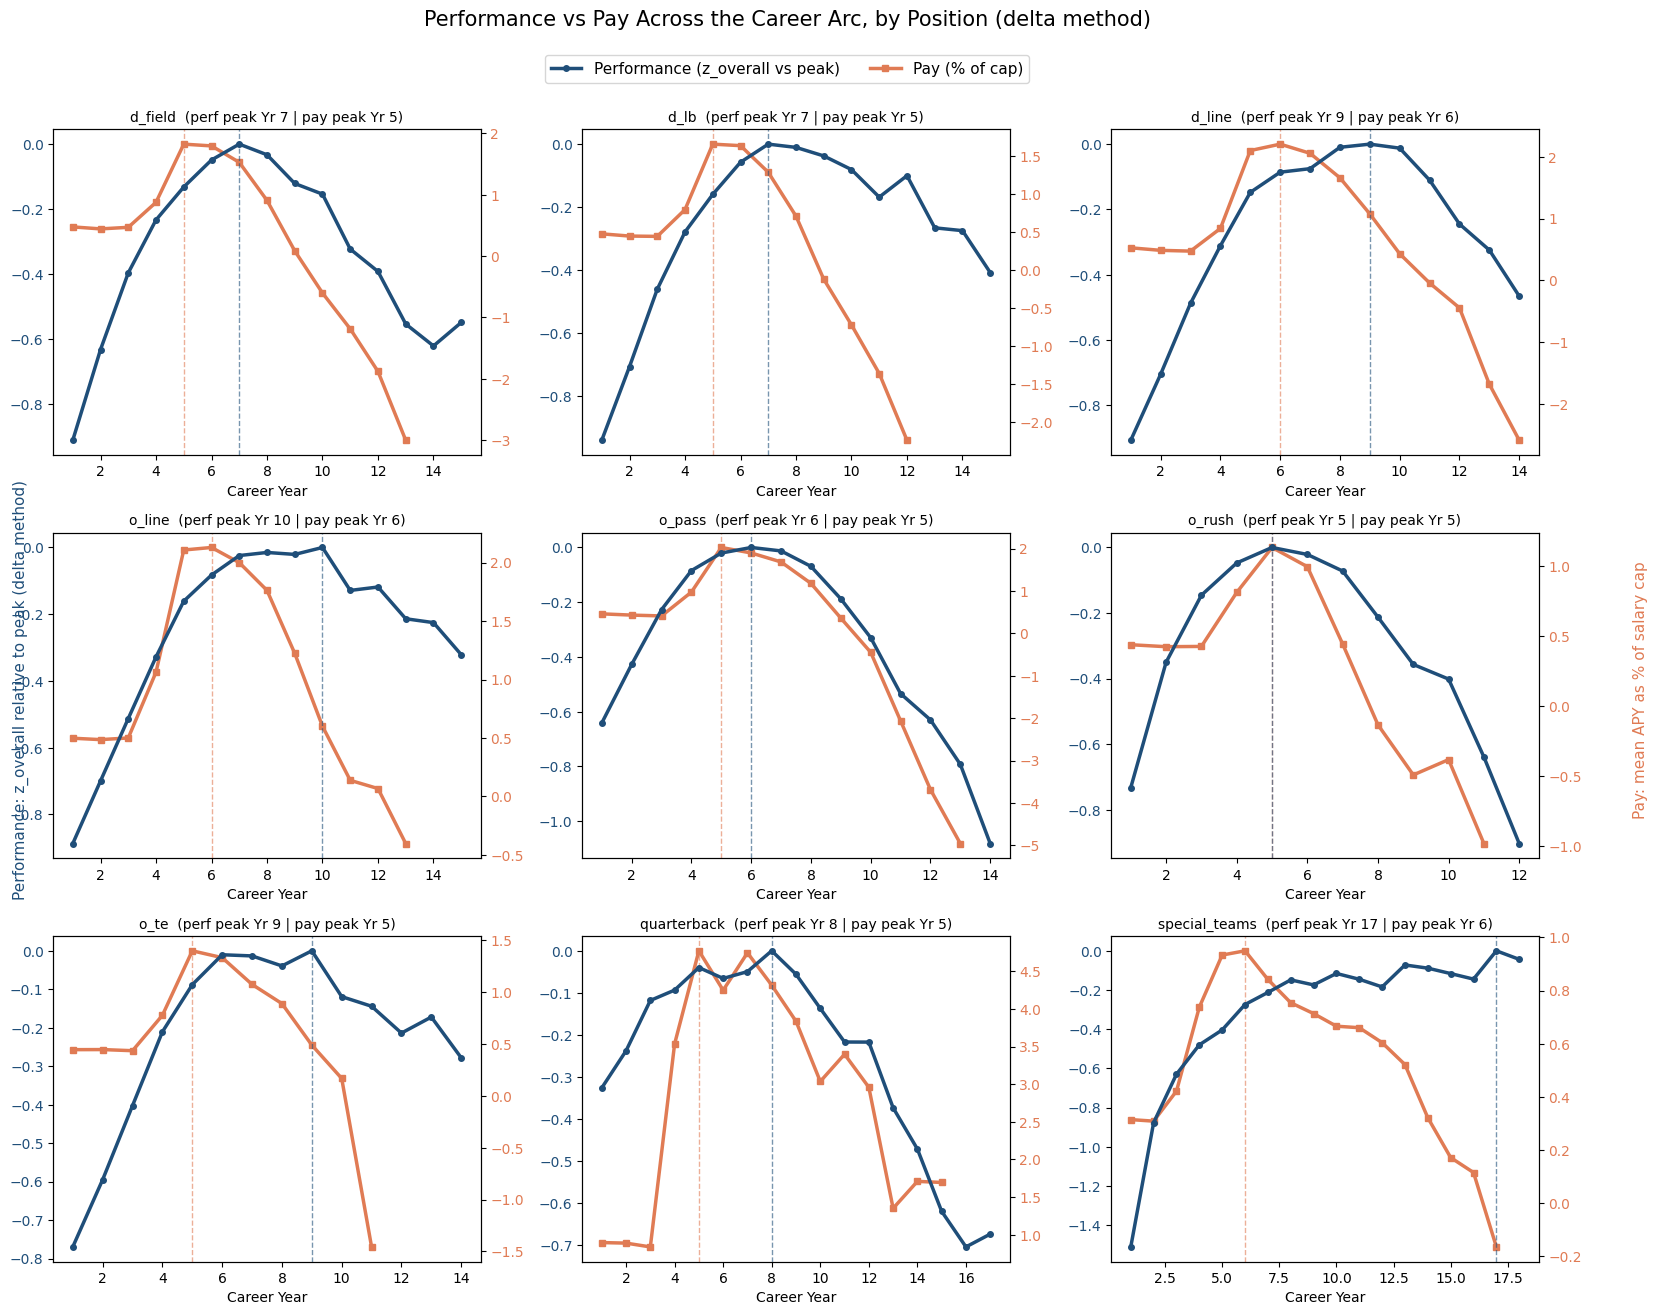

In [ ]:
groups = sorted(set(position_curves.keys()) & set(pay_curves.keys()))
ncols = 3
nrows = -(-len(groups) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4.2))
axes = axes.flatten()

PERF_COLOR = "#1f4e79"   # performance (left axis)
PAY_COLOR  = "#E07B54"   # pay (right axis)

for i, pos in enumerate(groups):
    ax = axes[i]                 # left axis: performance
    ax2 = ax.twinx()             # right axis: pay

    perf = position_curves[pos]
    pay  = pay_curves[pos]

    # --- performance (left) ---
    l1, = ax.plot(perf["age"], perf["curve_value"], color=PERF_COLOR,
                  linewidth=2.5, marker="o", markersize=4, label="Performance (z_overall vs peak)")
    perf_peak = perf.loc[perf["curve_value"].idxmax(), "age"]
    ax.axvline(perf_peak, color=PERF_COLOR, linestyle="--", linewidth=1, alpha=0.6)

    # --- pay (right) ---
    l2, = ax2.plot(pay["age"], pay["cap_pct"] * 100, color=PAY_COLOR,
                   linewidth=2.5, marker="s", markersize=4, label="Pay (% of cap)")
    pay_peak = pay.loc[pay["cap_pct"].idxmax(), "age"]
    ax2.axvline(pay_peak, color=PAY_COLOR, linestyle="--", linewidth=1, alpha=0.6)

    # cosmetics
    ax.set_title(f"{pos}  (perf peak Yr {int(perf_peak)} | pay peak Yr {int(pay_peak)})", fontsize=10)
    ax.set_xlabel("Career Year")
    ax.tick_params(axis="y", labelcolor=PERF_COLOR)
    ax2.tick_params(axis="y", labelcolor=PAY_COLOR)
    ax.set_zorder(ax2.get_zorder() + 1)   # keep perf line on top
    ax.patch.set_visible(False)

for j in range(len(groups), len(axes)):
    fig.delaxes(axes[j])

# shared axis labels
fig.text(0.07, 0.5, "Performance: z_overall relative to peak (delta method)",
         va="center", rotation="vertical", fontsize=11, color=PERF_COLOR)
fig.text(0.97, 0.5, "Pay: mean APY as % of salary cap",
         va="center", rotation="vertical", fontsize=11, color=PAY_COLOR)

# one shared legend
fig.legend([l1, l2], ["Performance (z_overall vs peak)", "Pay (% of cap)"],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01), fontsize=11)

plt.suptitle("Performance vs Pay Across the Career Arc, by Position (delta method)",
             y=1.04, fontsize=15)
plt.tight_layout(rect=[0.06, 0, 0.95, 1])
plt.show()

### Exploring how the combine impacts madden ratings

In [ ]:
madden_long = pd.read_parquet("/content/drive/MyDrive/ipynb stuff/madden_hist.parquet")
combine = nfl.load_combine().to_pandas() # nfl combine results

In [ ]:
combine_df = combine.dropna(subset="forty").merge(players[["pfr_id", "gsis_id", "draft_year"]], left_on = "pfr_id", right_on = "pfr_id", how = "left")

In [ ]:
rookie_seasons = madden_long.merge(players[["draft_year", "gsis_id"]], left_on="player_id", right_on = "gsis_id", how='left').query("year == draft_year")

In [ ]:
rookie_seasons_and_combine = rookie_seasons.merge(combine_df[["gsis_id", "forty"]], left_on="player_id", right_on="gsis_id", how="left")

In [ ]:
rookie_seasons_and_combine

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year,draft_year,gsis_id_x,gsis_id_y,forty
0,00-0020459,JAMALREYNOLDS_d_line,ReynJa20,Jamal Reynolds,def,d_line,DL,2001,GB,4.610860,79.000000,72.000000,83.000000,76.000000,78.000000,73.000000,88.00000,85.000000,64.000000,60.000000,13.928256,5,11,47.738742,52.942789,15.000000,21.000000,21.000000,21.00000,17.356663,20.805043,15.000000,14.519759,8.996859,23.991852,22.437692,33.000000,10.151774,11.892505,12.693256,12.293937,7.395690,14.332235,11.000000,12.000000,3.324223,27.272776,29.680041,69.000000,53.186884,22.930081,74.745695,19.000000,22.000000,1.439833,2001,2001.0,00-0020459,00-0020459,4.72
1,00-0020535,JUSTINSMITH_19790920,SmitJu20,Justin Smith,def,d_line,DL,2001,CIN,4.610860,79.000000,67.000000,82.000000,76.000000,85.000000,77.000000,80.00000,73.000000,66.000000,58.000000,7.920525,3,6,40.323669,59.834627,22.000000,21.000000,21.000000,21.00000,16.433431,20.294446,15.000000,8.629725,2.961450,18.548155,11.311415,19.000000,11.235782,11.530147,11.692559,6.724469,2.138416,16.285808,23.000000,22.000000,20.447276,25.551392,30.165120,72.000000,50.433495,13.792209,76.216600,20.000000,11.000000,3.217043,2001,2001.0,00-0020535,00-0020535,4.64
2,00-0020426,CASEYHAMPTON_19770903,HampCa00,Casey Hampton,def,d_line,DL,2001,PIT,4.610860,77.000000,63.000000,66.000000,59.000000,89.000000,90.000000,82.00000,87.000000,69.000000,48.000000,9.579246,3,6,35.761971,64.084072,24.000000,14.000000,14.000000,14.00000,12.866408,15.389567,31.000000,-5.764664,-5.385784,-1.178711,-7.282151,16.000000,6.692096,11.166714,13.290851,7.366448,2.750697,15.042041,18.000000,18.000000,-1.104908,16.861550,22.657078,82.000000,54.847755,7.175994,70.210879,11.000000,12.000000,4.719639,2001,2001.0,00-0020426,00-0020426,5.25
3,00-0020524,GERARDWARREN_d_line,WarrGe20,Gerard Warren,def,d_line,DL,2001,CLE,4.610860,76.000000,68.000000,77.000000,66.000000,85.000000,86.000000,85.00000,90.000000,64.000000,58.000000,9.322765,3,7,35.344868,58.098234,15.000000,20.000000,20.000000,20.00000,16.730251,20.169793,14.000000,6.159716,2.064359,9.003112,5.489941,30.000000,11.909426,11.950203,11.538211,7.432284,5.451204,15.074740,15.000000,20.000000,15.245089,20.165591,25.608706,79.000000,54.883390,6.512757,73.534821,18.000000,10.000000,3.707843,2001,2001.0,00-0020524,00-0020524,5.00
4,00-0020489,ANDRECARTER_d_line,CartAn20,Andre Carter,def,d_line,DL,2001,SF,4.610860,75.000000,70.000000,72.000000,74.000000,79.000000,73.000000,80.00000,79.000000,66.000000,55.000000,3.157469,4,5,43.595785,57.786312,11.000000,19.000000,19.000000,19.00000,19.153590,22.933768,14.000000,7.543041,-1.469502,25.255121,20.726918,19.000000,11.903602,12.196510,11.639022,9.595415,4.653976,19.316321,10.000000,32.000000,6.313320,33.531732,34.206993,70.000000,48.385150,19.021440,70.197263,10.000000,25.000000,3.612164,2001,2001.0,00-0020489,00-0020489,4.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5801,00-0040743,TYLERSHOUGH_19990928,None,Tyler Shough,off,quarterback,QB,2025,NO,4.520408,68.000000,77.000000,84.000000,84.000000,82.000000,56.000000,82.00000,81.000000,66.000000,73.000000,40.000000,4,7,75.000000,32.000000,92.000000,80.000000,81.000000,75.00000,83.000000,80.000000,67.000000,71.000000,38.000000,52.00000

Text(0.5, 1.0, 'Madden Speed Rookie Year vs Forty Time in Combine')

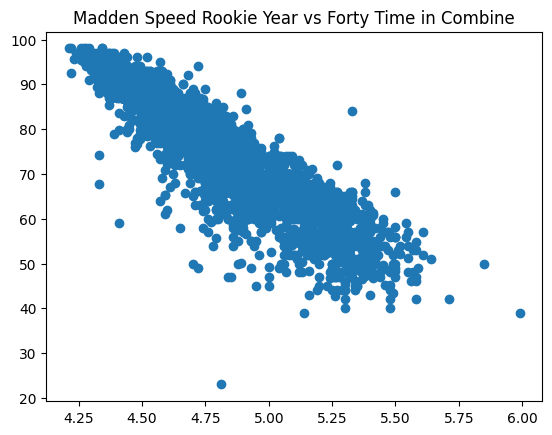

In [ ]:
plt.scatter(rookie_seasons_and_combine["forty"], rookie_seasons_and_combine["speed"])
plt.title("Madden Speed Rookie Year vs Forty Time in Combine")

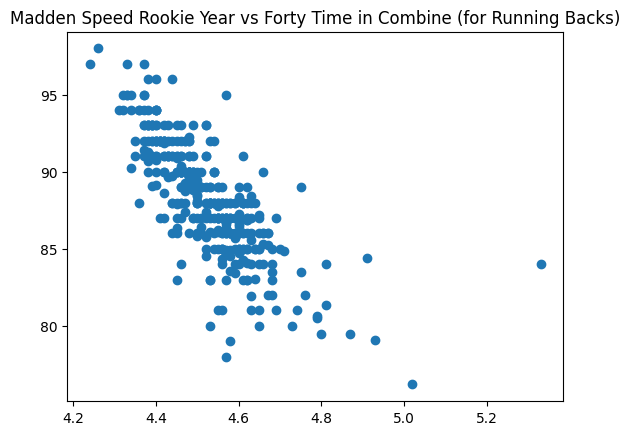

In [ ]:
plt.scatter(rookie_seasons_and_combine.query("position == 'RB'")["forty"], rookie_seasons_and_combine.query("position == 'RB'")["speed"])
plt.title("Madden Speed Rookie Year vs Forty Time in Combine (for Running Backs)")
plt.show()

In [ ]:
rookie_seasons_and_combine.query("position == 'RB'")["forty"].corr(rookie_seasons_and_combine.query("position == 'RB'")["speed"])

np.float64(-0.76746933864537)